In [1]:
# Mempersiapkan tools yang akan di gunakan - import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# IMPORT DATA

1. Insert Amazon Sales Data = pd.read_csv("Downloads/Amazon (ihsan & rafif).csv")
2. Membuat dataframe (df_rf) dengan mengimpor dataset yang akan digunakan untuk proses analisis.
3. Dataset yang digunakan berupa file berformat .csv yang disimpan secara lokal, kemudian dipanggil menggunakan library pandas.

In [2]:
df_rf = pd.read_csv("Downloads/Amazon (ihsan & rafif).csv")
df_rf.head(5)

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,6/13/2013,6/17/2013,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


# EKSPLORASI DATA

In [3]:
# Eksplorasi Data 1 
# .info() berfungsi untuk menampilakan informasi umum dataset (jumlah data, nama atribut/kolom, tipe data, serta jumlah nilai non-null pada setiap atribut).
print("===== INFO DATAFRAME =====")
df_rf.info()

===== INFO DATAFRAME =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      3203 non-null   object 
 1   Order Date    3203 non-null   object 
 2   Ship Date     3203 non-null   object 
 3   EmailID       3203 non-null   object 
 4   Geography     3203 non-null   object 
 5   Category      3203 non-null   object 
 6   Product Name  3203 non-null   object 
 7   Sales         3203 non-null   float64
 8   Quantity      3203 non-null   float64
 9   Profit        3203 non-null   float64
dtypes: float64(3), object(7)
memory usage: 250.4+ KB


In [4]:
# Eksplorasi Data 2
# .describe() digunakan untuk menampilkan statistik deskriptif pada atribut numerik
df_rf.describe().round(1) # .round berfungsi untuk membulatkan angka menjadi 1 digit di belakang koma.

,Sales,Quantity,Profit
count,3203.0,3203.0,3203.0
mean,226.5,3.8,33.8
std,524.9,2.3,174.1
min,1.0,1.0,-3400.0
25%,19.4,2.0,3.8
50%,60.8,3.0,11.2
75%,215.8,5.0,33.0
max,14000.0,14.0,6720.0


In [5]:
# Eksplorasi Data 3
# .describe(include="object") digunakan untuk menampilkan statistik deskriptif pada atribut kategorikal (object),
print("\n===== DESCRIPTIVE STATISTIC - CATEGORICAL =====")
df_rf.describe(include="object")


===== DESCRIPTIVE STATISTIC - CATEGORICAL =====


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name
count,3203,3203,3203,3203,3203,3203,3203
unique,1611,845,911,686,170,17,1494
top,CA-2013-165330,12/3/2014,12/7/2014,WilliamBrown@gmail.com,"United States,Los Angeles,California",Binders,Staples
freq,11,19,27,24,747,471,60


In [6]:
# Eksplorasi Data 4
# .shape digunakan untuk menampilkan dimensi dataset, yaitu jumlah baris (rows) dan jumlah kolom (columns) yang terdapat dalam dataset.
row, col = df_rf.shape
print(f"Terdapat {row} Baris dan {col} Kolom")

Terdapat 3203 Baris dan 10 Kolom


In [7]:
# Eksplorasi Data 5
# Melakukan pengecekan duplicate data dan missing values untuk mengetahui kualitas data sebelum dilakukan preprocessing lebih lanjut.

# Mengecek jumlah data duplikat
duplicate_checking = df_rf.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_checking}")

# Mengecek jumlah missing values pada setiap kolom
missing_values_checking = df_rf.isnull().sum()
print("\nJumlah missing values pada setiap kolom:")
print(missing_values_checking)

Jumlah data duplikat: 0

Jumlah missing values pada setiap kolom:
Order ID        0
Order Date      0
Ship Date       0
EmailID         0
Geography       0
Category        0
Product Name    0
Sales           0
Quantity        0
Profit          0
dtype: int64


**Hasil** : tidak ditemukan adanya duplikat dan missing value pada dataset

In [8]:
# Eksplorasi Data 6
# .dtypes digunakan untuk mengidentifikasi tipe data pada setiap atribut/kolom dalam dataset.
df_rf.dtypes

Order ID         object
Order Date       object
Ship Date        object
EmailID          object
Geography        object
Category         object
Product Name     object
Sales           float64
Quantity        float64
Profit          float64
dtype: object

## Analisis Distribusi Data Numerikal (visualisasi histogram)

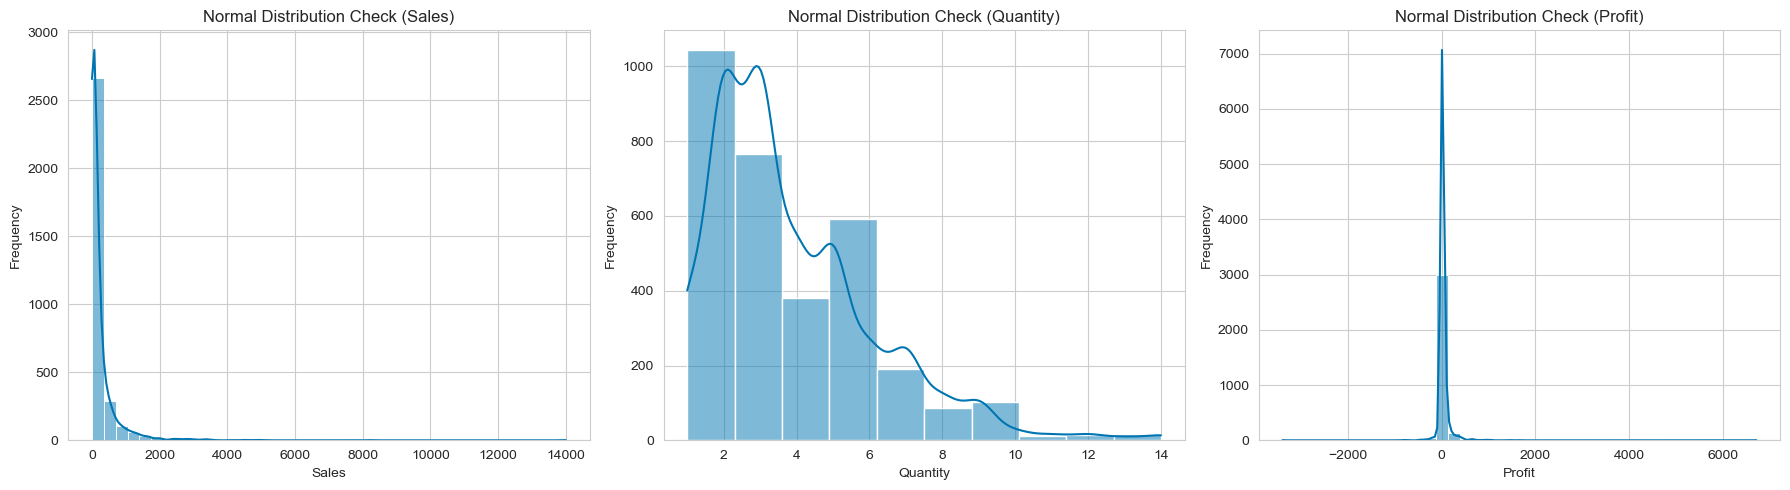

In [9]:
# Eksplorasi Data 7
# Visualisasi distribusi data numerik menggunakan histogram untuk melihat pola persebaran data dan mengidentifikasi
# apakah distribusi data cenderung normal atau tidak.

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Daftar kolom dan jumlah bins
kolom_bins = {"Sales": 40, "Quantity": 10, "Profit": 40}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (kolom, bins) in zip(axes, kolom_bins.items()):
    sns.histplot(df_rf[kolom], bins=bins, kde=True, color="#0075b2", ax=ax)
    ax.set_title(f"Normal Distribution Check ({kolom})")
    ax.set_xlabel(kolom)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Analisis Distribusi Data Kategorikal (Proporsi)

In [10]:
# Eksplorasi Data 8
# Distribusi data kategorikal 

cat_cols = df_rf.select_dtypes(include=["object"]).columns

for col in cat_cols:

    total_data = df_rf[col].shape[0]
    total_unique = df_rf[col].nunique()

    persen_unique = (total_unique / total_data * 100)

    print(f"\n===== {col.upper()} =====")

    print(
        f"Jumlah Unique : "
        f"{total_unique} dari {total_data} "
        f"({persen_unique:.2f}%)"
    )

    distribusi = (df_rf[col].value_counts(dropna=False,normalize=True).mul(100).round(2))

    print("\nDistribusi (%):")
    print(distribusi)


===== ORDER ID =====
Jumlah Unique : 1611 dari 3203 (50.30%)

Distribusi (%):
Order ID
CA-2013-165330    0.34
CA-2011-106439    0.28
CA-2012-104346    0.28
CA-2012-164882    0.28
CA-2014-117457    0.28
                  ... 
CA-2014-123701    0.03
US-2011-167262    0.03
CA-2014-108091    0.03
CA-2012-144722    0.03
CA-2014-119914    0.03
Name: proportion, Length: 1611, dtype: float64

===== ORDER DATE =====
Jumlah Unique : 845 dari 3203 (26.38%)

Distribusi (%):
Order Date
12/3/2014     0.59
12/12/2013    0.56
12/9/2014     0.53
11/13/2014    0.47
12/7/2013     0.47
              ... 
3/15/2012     0.03
5/9/2013      0.03
5/19/2014     0.03
3/13/2014     0.03
4/12/2012     0.03
Name: proportion, Length: 845, dtype: float64

===== SHIP DATE =====
Jumlah Unique : 911 dari 3203 (28.44%)

Distribusi (%):
Ship Date
12/7/2014     0.84
12/16/2012    0.62
12/13/2014    0.47
11/11/2011    0.44
12/31/2013    0.44
              ... 
12/8/2012     0.03
12/19/2011    0.03
10/19/2013    0.03
4/29/2

## Konsistensi Data Kategorikal

In [11]:
# Eksplorasi Data 9
# Melakukan pengecekan kategori unik (unique values) pada atribut kategorikal untuk mengidentifikasi potensi inkonsistensi penulisan data.
# proporsi data category

cat_cols = df_rf.select_dtypes(include=["object"]).columns

for col in cat_cols:
    print(f"\n===== {col.upper()} =====")
    print(df_rf[col].value_counts(dropna=False))


===== ORDER ID =====
Order ID
CA-2013-165330    11
CA-2011-106439     9
CA-2012-104346     9
CA-2012-164882     9
CA-2014-117457     9
                  ..
CA-2014-123701     1
US-2011-167262     1
CA-2014-108091     1
CA-2012-144722     1
CA-2014-119914     1
Name: count, Length: 1611, dtype: int64

===== ORDER DATE =====
Order Date
12/3/2014     19
12/12/2013    18
12/9/2014     17
11/13/2014    15
12/7/2013     15
              ..
3/15/2012      1
5/9/2013       1
5/19/2014      1
3/13/2014      1
4/12/2012      1
Name: count, Length: 845, dtype: int64

===== SHIP DATE =====
Ship Date
12/7/2014     27
12/16/2012    20
12/13/2014    15
11/11/2011    14
12/31/2013    14
              ..
12/8/2012      1
12/19/2011     1
10/19/2013     1
4/29/2014      1
9/17/2011      1
Name: count, Length: 911, dtype: int64

===== EMAILID =====
EmailID
WilliamBrown@gmail.com       24
ArthurPrichep@gmail.com      23
RickWilson@gmail.com         19
GregGuthrie@gmail.com        17
ZuschussCarroll@gmail

In [12]:
print("=== Inkonsistensi Kategori ===")
cat_cols = df_rf.select_dtypes(include='object').columns

cat_values = []

for col in cat_cols:
    cat_values.append({'column': col,'unique_values': (df_rf[col].dropna().unique().tolist()),'n_unique': (df_rf[col].nunique(dropna=True))})

cat_values_df = pd.DataFrame(cat_values)

cat_values_df.head(20)

=== Inkonsistensi Kategori ===


,column,unique_values,n_unique
0,Order ID,"[CA-2013-138688, CA-2011-115812, CA-2013-16138...",1611
1,Order Date,"[6/13/2013, 6/9/2011, 12/6/2013, 5/13/2011, 8/...",845
2,Ship Date,"[6/17/2013, 6/14/2011, 12/11/2013, 5/15/2011, ...",911
3,EmailID,"[DarrinVanHuff@gmail.com, BrosinaHoffman@gmail...",686
4,Geography,"[United States,Los Angeles,California, United ...",170
5,Category,"[Labels, Furnishings, Art, Phones, Binders, Ap...",17
6,Product Name,[Self-Adhesive Address Labels for Typewriters ...,1494


**Temuan**:

Pada kolom Product Name, penulisan nama produk tidak konsisten karena terdapat potensi perbedaan format seperti penggunaan huruf besar/kecil (capitalization)

In [13]:
cat_cols = (df_rf.select_dtypes(include="object").drop(columns=["Order Date", "Ship Date"]).columns)

for col in cat_cols:

    print(f"\n===== {col.upper()} =====")
    print(f"Jumlah Unique: " f"{df_rf[col].nunique()}")
    print(f"\nDistribusi {col}")
    print(df_rf[col].dropna().unique()[:10])


===== ORDER ID =====
Jumlah Unique: 1611

Distribusi Order ID
['CA-2013-138688' 'CA-2011-115812' 'CA-2013-161389' 'CA-2011-167164'
 'CA-2011-143336' 'CA-2012-106320' 'CA-2013-121755' 'CA-2013-101343'
 'CA-2012-135545' 'CA-2011-106376']

===== EMAILID =====
Jumlah Unique: 686

Distribusi EmailID
['DarrinVanHuff@gmail.com' 'BrosinaHoffman@gmail.com'
 'IreneMaddox@gmail.com' 'AlejandroGrove@gmail.com'
 'ZuschussDonatelli@gmail.com' 'EmilyBurns@gmail.com'
 'EricHoffmann@gmail.com' 'RubenAusman@gmail.com' 'KunstMiller@gmail.com'
 'BrendanSweed@gmail.com']

===== GEOGRAPHY =====
Jumlah Unique: 170

Distribusi Geography
['United States,Los Angeles,California' 'United States,Seattle,Washington'
 'United States,West Jordan,Utah' 'United States,San Francisco,California'
 'United States,Orem,Utah' 'United States,Gilbert,Arizona'
 'United States,Portland,Oregon' 'United States,Aurora,Colorado'
 'United States,Phoenix,Arizona' 'United States,Roseville,California']

===== CATEGORY =====
Jumlah Uniq

In [14]:
# Eksplorasi Data 10
# Melakukan pengecekan nilai unik pada atribut numerik bertipe integer untuk memahami variasi data
num_cols = df_rf.select_dtypes(include=["float64"]).columns
for col in num_cols:
    print(f"\nDistribusi {col}")
    print(df_rf[col].value_counts(dropna=False))


Distribusi Sales
Sales
12.96     26
19.44     20
32.40     13
6.48       9
25.92      9
          ..
65.79      1
219.17     1
160.96     1
66.05      1
243.16     1
Name: count, Length: 2295, dtype: int64

Distribusi Quantity
Quantity
3.0     765
2.0     761
5.0     405
4.0     380
1.0     283
7.0     191
6.0     186
8.0      87
9.0      83
10.0     19
12.0     13
11.0     12
14.0     11
13.0      7
Name: count, dtype: int64

Distribusi Profit
Profit
 6.22      25
 0.00      22
 9.33      20
 15.55     11
 3.11       9
           ..
 136.62     1
-195.48     1
 18.50      1
 4.35       1
 72.95      1
Name: count, Length: 2164, dtype: int64


# DATA CLEANING

## Duplicate Handling

In [15]:
# Data Cleaning 1
# Melakukan pengecekan ulang duplicate data untuk mengetahui apakah terdapat baris data yang sama (duplikat) pada dataset.
df_rf_clean = df_rf.copy()

total_duplicate = df_rf_clean.duplicated().sum()
if total_duplicate == 0:
    print("Tidak ditemukan data duplikat pada dataset.")
else:
    print(f"Ditemukan {total_duplicate} data duplikat pada dataset.")

Tidak ditemukan data duplikat pada dataset.


## Missing Value Handling

In [16]:
# Data Cleaning 2
# Melakukan pengecekan ulang missing values untuk memastikan tidak terdapat data kosong (null values) pada dataset.
total_missing_value = df_rf_clean.isnull().sum().sum()
if total_missing_value == 0:
    print("Tidak ditemukan missing values pada dataset.")
else:
    print(f"Ditemukan {total_missing_value} missing values pada dataset.")

Tidak ditemukan missing values pada dataset.


## Inkonsisten Data Handling

In [17]:
# Data Cleaning 3
# Melakukan standarisasi format data pada atribut bertipe object untuk menjaga konsistensi penulisan, seperti menghapus spasi berlebih
# (leading/trailing spaces) serta menyeragamkan penulisan Product Name menjadi huruf kecil (lowercase).

df_rf_clean['Product Name'] = df_rf_clean['Product Name'].str.strip().str.lower()

df_rf_clean = df_rf_clean.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# Validasi ulang atribut kategorikal setelah cleaning, untuk memastikan format data telah konsisten.
for col in df_rf_clean.select_dtypes(include= "object").drop(columns=["Order Date","Ship Date"]):
    print(f"\nKolom: {col}")
    print(df_rf_clean[col].unique()[:20])


Kolom: Order ID
['CA-2013-138688' 'CA-2011-115812' 'CA-2013-161389' 'CA-2011-167164'
 'CA-2011-143336' 'CA-2012-106320' 'CA-2013-121755' 'CA-2013-101343'
 'CA-2012-135545' 'CA-2011-106376' 'CA-2011-139451' 'CA-2013-109806'
 'US-2014-109484' 'CA-2014-157833' 'US-2012-156867' 'CA-2012-110457'
 'US-2014-107272' 'US-2013-125969' 'CA-2013-145583' 'CA-2014-106180']

Kolom: EmailID
['DarrinVanHuff@gmail.com' 'BrosinaHoffman@gmail.com'
 'IreneMaddox@gmail.com' 'AlejandroGrove@gmail.com'
 'ZuschussDonatelli@gmail.com' 'EmilyBurns@gmail.com'
 'EricHoffmann@gmail.com' 'RubenAusman@gmail.com' 'KunstMiller@gmail.com'
 'BrendanSweed@gmail.com' 'DuaneNoonan@gmail.com' 'JimSink@gmail.com'
 'RogerBarcio@gmail.com' 'KatherineDucich@gmail.com'
 'LenaCacioppo@gmail.com' 'DaveKipp@gmail.com' 'TroyStaebel@gmail.com'
 'LindsayShagiari@gmail.com' 'LenaCreighton@gmail.com'
 'SallyHughsby@gmail.com']

Kolom: Geography
['United States,Los Angeles,California' 'United States,Seattle,Washington'
 'United States,We

In [18]:
df_rf_clean['Product Name'].nunique()

1494

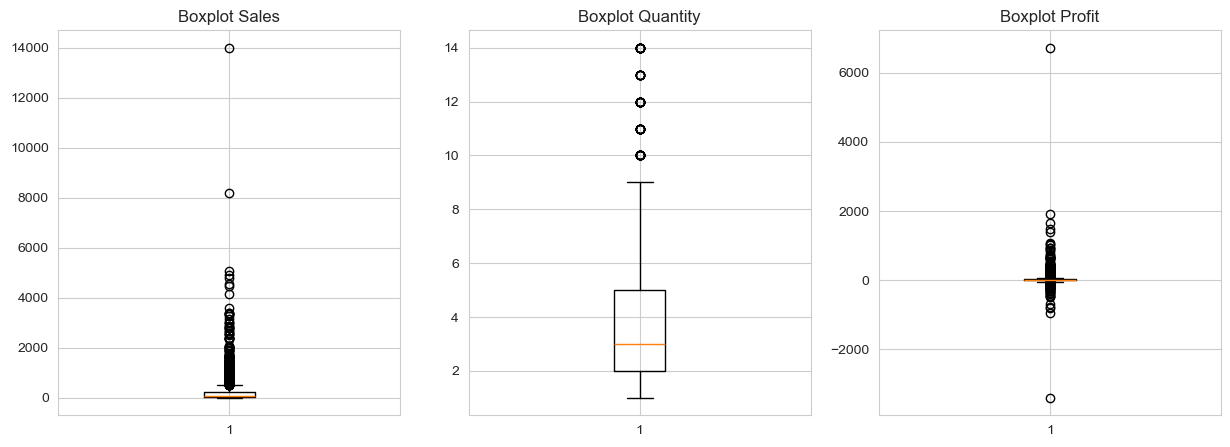

In [19]:
# Data Cleaning 4
# Visualisasi boxplot untuk mendeteksi outlier

import matplotlib.pyplot as plt

kolom = ["Sales", "Quantity", "Profit"]

plt.figure(figsize=(15,5))

for i, col in enumerate(kolom, 1):

    plt.subplot(1, 3, i)
    plt.boxplot(df_rf_clean[col])
    plt.title(f"Boxplot {col}")

plt.show()

In [20]:
# Data Cleaning 4b.1
# Mengidentifikasi outlier pada atribut "Sales"
# menggunakan metode Interquartile Range (IQR).
Q1 = df_rf_clean["Sales"].quantile(0.25)
Q3 = df_rf_clean["Sales"].quantile(0.75)
IQR = Q3-Q1

# Menentukan batas bawah dan batas atas outlier
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

# Mengidentifikasi data outlier
outlier_iqr_sales = df_rf_clean[(df_rf_clean["Sales"] < lower) | (df_rf_clean["Sales"] > upper)]

jumlah_outlier = len(outlier_iqr_sales)
print(f"Jumlah outlier sales: {jumlah_outlier}")

# Menghitung persentase outlier terhadap total data
persentase_outlier = (jumlah_outlier / len(df_rf_clean)) * 100
print(f"Persentase outlier quantity: {persentase_outlier:.2f}%")

outlier_iqr_sales.head(5)

Jumlah outlier sales: 368
Persentase outlier quantity: 11.49%


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
3,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,mitel 5320 ip phone voip phone,907.15,4.0,90.72
6,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Tables,chromcraft rectangular conference tables,1706.18,9.0,85.31
7,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,konftel 250 conferenceâ phoneâ - charcoal black,911.42,4.0,68.36
13,CA-2012-106320,9/25/2012,9/30/2012,EmilyBurns@gmail.com,"United States,Orem,Utah",Tables,bretford cr4500 series slim rectangular table,1044.63,3.0,240.26
21,CA-2011-106376,12/5/2011,12/10/2011,BrendanSweed@gmail.com,"United States,Gilbert,Arizona",Art,hunt boston model 1606 high-volume electric pe...,1113.02,8.0,111.30


In [21]:
# Data Cleaning 4b.2
# Mengidentifikasi outlier pada atribut "Quantity"
# menggunakan metode Interquartile Range (IQR).
Q1 = df_rf_clean["Quantity"].quantile(0.25)
Q3 = df_rf_clean["Quantity"].quantile(0.75)
IQR = Q3-Q1

# Menentukan batas bawah dan batas atas outlier
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

# Mengidentifikasi data outlier
outlier_iqr_quantity = df_rf_clean[(df_rf_clean["Quantity"] < lower) | (df_rf_clean["Quantity"] > upper)]

jumlah_outlier2 = len(outlier_iqr_quantity)
print(f"Jumlah outlier Quantity: {jumlah_outlier2}")

# Menghitung persentase outlier terhadap total data
persentase_outlier2 = (jumlah_outlier2 / len(df_rf_clean)) * 100
print(f"Persentase outlier quantity: {persentase_outlier2:.2f}%")

outlier_iqr_quantity.head(5)

Jumlah outlier Quantity: 62
Persentase outlier quantity: 1.94%


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
44,CA-2013-145583,10/14/2013,10/20/2013,LenaCreighton@gmail.com,"United States,Roseville,California",Furnishings,longer-life soft white bulbs,43.12,14.0,20.70
72,CA-2013-145625,9/12/2013,9/18/2013,KellyCollister@gmail.com,"United States,San Diego,California",Accessories,logitechâ p710e mobile speakerphone,3347.37,13.0,636.00
107,US-2011-119137,7/23/2011,7/27/2011,ArthurGainer@gmail.com,"United States,Tucson,Arizona",Accessories,microsoft natural keyboard elite,479.04,10.0,-29.94
120,CA-2014-117457,12/9/2014,12/13/2014,KeithHerrera@gmail.com,"United States,San Francisco,California",Bookcases,o'sullivan 4-shelf bookcase in odessa pine,1336.83,13.0,31.45
186,CA-2012-149713,9/18/2012,9/22/2012,TrudyGlocke@gmail.com,"United States,Long Beach,California",Paper,personal creations ink jet cards and labels,160.72,14.0,78.75


In [22]:
# Data Cleaning 4b.3
# Mengidentifikasi outlier pada atribut "Profit"
# menggunakan metode Interquartile Range (IQR).
Q1 = df_rf_clean["Profit"].quantile(0.25)
Q3 = df_rf_clean["Profit"].quantile(0.75)
IQR = Q3-Q1

# Menentukan batas bawah dan batas atas outlier
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

# Mengidentifikasi data outlier
outlier_iqr_profit = df_rf_clean[(df_rf_clean["Profit"] < lower) | (df_rf_clean["Profit"] > upper)]

jumlah_outlier3 = len(outlier_iqr_profit)
print(f"Jumlah outlier Quantity: {jumlah_outlier3}")

# Menghitung persentase outlier terhadap total data
persentase_outlier3 = (jumlah_outlier3 / len(df_rf_clean)) * 100
print(f"Persentase outlier quantity: {persentase_outlier3:.2f}%")

outlier_iqr_profit.head(5)

Jumlah outlier Quantity: 465
Persentase outlier quantity: 14.52%


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
3,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,mitel 5320 ip phone voip phone,907.15,4.0,90.72
6,CA-2011-115812,6/9/2011,6/14/2011,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Tables,chromcraft rectangular conference tables,1706.18,9.0,85.31
8,CA-2013-161389,12/6/2013,12/11/2013,IreneMaddox@gmail.com,"United States,Seattle,Washington",Binders,fellowes pb200 plastic comb binding machine,407.98,3.0,132.59
13,CA-2012-106320,9/25/2012,9/30/2012,EmilyBurns@gmail.com,"United States,Orem,Utah",Tables,bretford cr4500 series slim rectangular table,1044.63,3.0,240.26
21,CA-2011-106376,12/5/2011,12/10/2011,BrendanSweed@gmail.com,"United States,Gilbert,Arizona",Art,hunt boston model 1606 high-volume electric pe...,1113.02,8.0,111.30


**Keputusan:** 

Outlier tidak dihapus karena dianggap merepresentasikan transaksi nyata, bukan kesalahan input data. Nilai ekstrem pada Sales dan Profit dapat berasal dari transaksi bernilai tinggi atau produk premium, sedangkan pada Quantity kemungkinan mencerminkan pembelian dalam jumlah besar (bulk order) yang masih valid secara bisnis. Oleh karena itu, outlier tetap dipertahankan untuk menjaga representasi data tetap sesuai kondisi aktual.

In [23]:
print("===== INFO DATAFRAME =====")
df_rf_clean.info()

===== INFO DATAFRAME =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      3203 non-null   object 
 1   Order Date    3203 non-null   object 
 2   Ship Date     3203 non-null   object 
 3   EmailID       3203 non-null   object 
 4   Geography     3203 non-null   object 
 5   Category      3203 non-null   object 
 6   Product Name  3203 non-null   object 
 7   Sales         3203 non-null   float64
 8   Quantity      3203 non-null   float64
 9   Profit        3203 non-null   float64
dtypes: float64(3), object(7)
memory usage: 250.4+ KB


# DATA MANIPULATION

## Uji Normalitas Data Numerik

In [24]:
from scipy.stats import shapiro

# List kolom yang ingin dicek
kolom_numerik = ["Sales","Quantity","Profit"]

for col in kolom_numerik:
    # Menghapus NaN jika ada agar tidak error
    data = df_rf_clean[col].dropna()
    
    stat, p = shapiro(data)
    
    print(f"=== Uji Normalitas Kolom: {col} ===")
    print(f"Statistik Uji: {stat:.4f}")
    print(f"P-Value      : {p:.10f}")
    
    if p > 0.05:
        print("Hasil        : Data berdistribusi Normal")
    else:
        print("Hasil        : Data tidak berdistribusi Normal")
    print("-" * 46)


=== Uji Normalitas Kolom: Sales ===
Statistik Uji: 0.3990
P-Value      : 0.0000000000
Hasil        : Data tidak berdistribusi Normal
----------------------------------------------
=== Uji Normalitas Kolom: Quantity ===
Statistik Uji: 0.8814
P-Value      : 0.0000000000
Hasil        : Data tidak berdistribusi Normal
----------------------------------------------
=== Uji Normalitas Kolom: Profit ===
Statistik Uji: 0.2435
P-Value      : 0.0000000000
Hasil        : Data tidak berdistribusi Normal
----------------------------------------------


## Uji Normalitas Data (Setelah Cleaning)

Metode Original     | P-Value: 0.00000000000000000000
Metode Square Root  | P-Value: 0.00000000000000000000
Metode Log          | P-Value: 0.00000000000000000000
Metode Box-Cox      | P-Value: 0.00000000000000347772


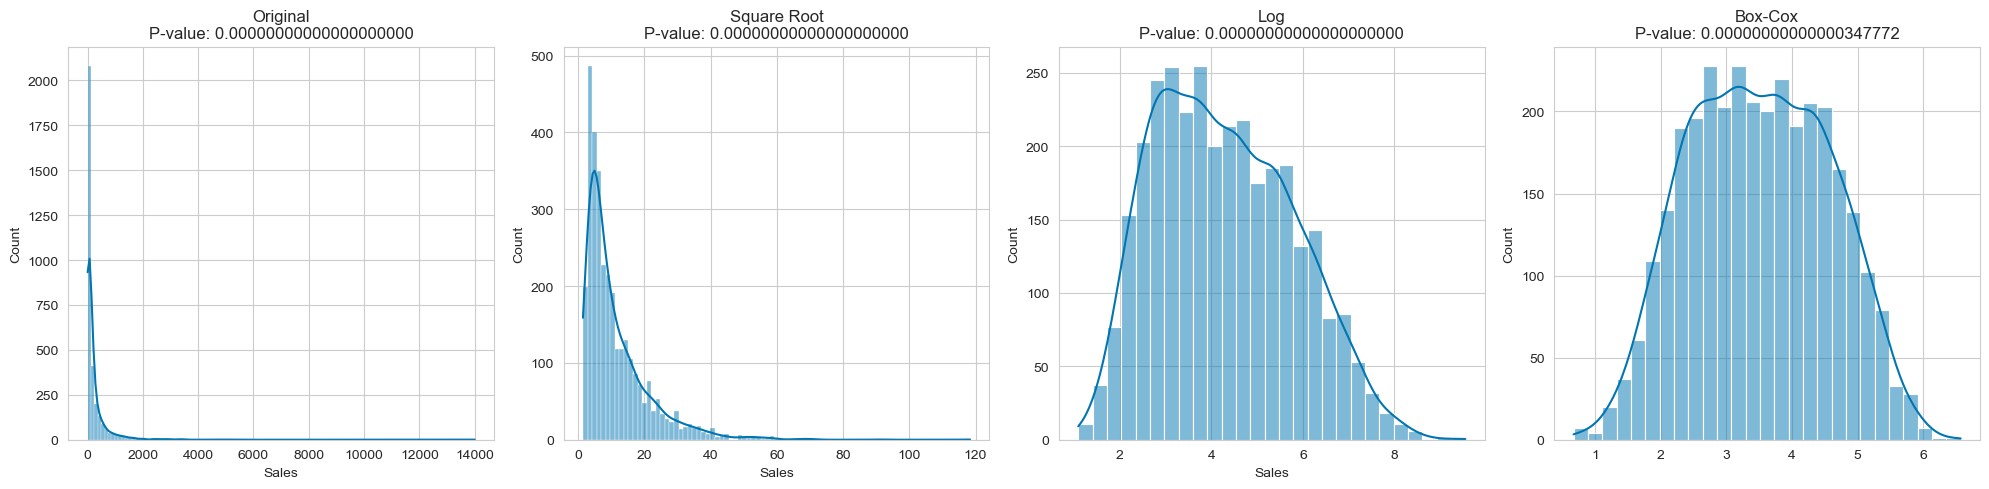

Metode Original     | P-Value: 0.00000000000000000000
Metode Square Root  | P-Value: 0.00000000000000000000
Metode Log          | P-Value: 0.00000000000000000000
Metode Box-Cox      | P-Value: 0.00000000000000000000


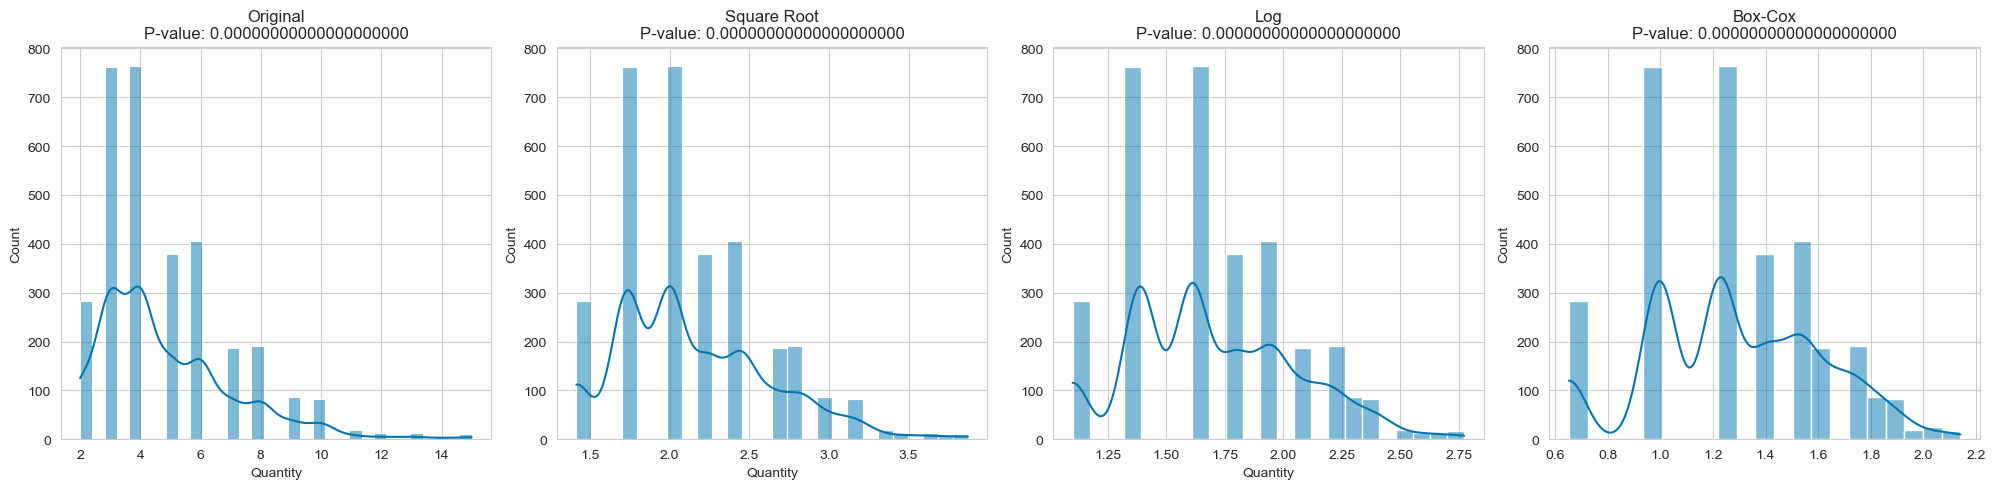

In [25]:
import numpy as np
import scipy.stats as stats

sns.set_style("whitegrid")

def try_transformations(df_rf, column):
    
    # 1. Siapkan data_ori (Menambahkan nilai 1 untuk menghindari log(0) atau boxcox(0))
    data_ori = df_rf[column] + 1

    # Metode transformasi
    data_sqrt = np.sqrt(data_ori) # Metode Square Root
    data_log = np.log1p(data_ori) # Metode Log Transformation
    
    # Box-Cox transformation
    # Box-cox mengembalikan data dan nilai lambda optimal
    data_boxcox, lam = stats.boxcox(data_ori)
    
    # List untuk looping visualisasi
    methods = [("Original",data_ori),("Square Root",data_sqrt),("Log",data_log),('Box-Cox',data_boxcox)]
    
    # Visualisasi Perbandingan
    plt.figure(figsize=(20, 5))
    
    for i, (name, data) in enumerate(methods):
        plt.subplot(1, 4, i+1)
        sns.histplot(data, kde=True, color="#0075b2")
        
        # Hitung Shapiro-Wilk
        stat, p = stats.shapiro(data)
        plt.title(f"{name}\nP-value: {p:.20f}")
        print(f"Metode {name:12} | P-Value: {p:.20f}")
    
    plt.tight_layout()
    plt.show()

kolom_numerik = ["Sales", "Quantity"]
                 # "Profit"

for col in kolom_numerik:
    try_transformations(df_rf_clean, col)

**Tidak dilakukan uji normalitas pada kolom profit karena terdapat value yang minus (-)**

Berdasarkan hasil uji normalisasi data,diketahui bahwa distribusi data masih cenderung tidak normal, meskipun telah dilakukan pengujian menggunakan tiga metode yaitu Square Root, Log Transformation,dan Box-Cox.

### Data Type Conversion

In [26]:
df_rf_clean.dtypes

Order ID         object
Order Date       object
Ship Date        object
EmailID          object
Geography        object
Category         object
Product Name     object
Sales           float64
Quantity        float64
Profit          float64
dtype: object

In [27]:
# Data Manipulation 1

# Melakukan type conversion pada atribut "Date" dari object menjadi datetime agar dapat digunakan untuk analisis berbasis waktu.
df_rf_manipulation = df_rf_clean.copy()
date_columns = ["Order Date","Ship Date"]

for col in date_columns:df_rf_manipulation[col] = (pd.to_datetime(df_rf_manipulation[col],errors="coerce"))
df_rf_manipulation.head(5)

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,self-adhesive address labels for typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,eldon expressions wood and plastic desk access...,48.86,7.0,14.17
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,newell 322,7.28,4.0,1.97
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,mitel 5320 ip phone voip phone,907.15,4.0,90.72
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,dxl angle-view binders with locking rings by s...,18.50,3.0,5.78


In [28]:
# Data Manipulation 2

# Melakukan type conversion pada atribut "Quantity" dari float64 menjadi Int64 karena nilai bukan bilangan desimal.
df_rf_manipulation["Quantity"] = pd.to_numeric(df_rf_manipulation["Quantity"], errors="coerce").astype("int64")
# df_rf_manipulation["Quantity"].astype("int64")
df_rf_manipulation.head(5)

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,self-adhesive address labels for typewriters b...,14.62,2,6.87
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,eldon expressions wood and plastic desk access...,48.86,7,14.17
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,newell 322,7.28,4,1.97
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,mitel 5320 ip phone voip phone,907.15,4,90.72
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,dxl angle-view binders with locking rings by s...,18.50,3,5.78


In [29]:
# Memastikan tipe data atribut sudah terganti 
print("Tipe data kolom:")
print("Order Date:",df_rf_manipulation["Order Date"].dtype)
print("Ship Date:",df_rf_manipulation["Ship Date"].dtype)
print("Quantity:",df_rf_manipulation["Quantity"].dtype)

# telah berhasil dikonversi
# menjadi datetime dan Int64.

Tipe data kolom:
Order Date: datetime64[ns]
Ship Date: datetime64[ns]
Quantity: int64


In [30]:
df_rf_manipulation.head(5)

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,self-adhesive address labels for typewriters b...,14.62,2,6.87
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,eldon expressions wood and plastic desk access...,48.86,7,14.17
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,newell 322,7.28,4,1.97
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,mitel 5320 ip phone voip phone,907.15,4,90.72
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,dxl angle-view binders with locking rings by s...,18.50,3,5.78


### Feature Engineering

In [31]:
# Data Manipulation 3

# Membuat dataset baru agar data asli tetap aman dan tidak berubah
df_rf_manipulation2 = (df_rf_manipulation.copy()) 

# Split Geography menjadi 3 kolom
geo_split = df_rf_manipulation2["Geography"].str.split(",", expand=True)

# Rapihkan spasi
geo_split = geo_split.apply(lambda x: x.str.strip())

# Rename kolom
geo_split.columns = ["Country", "City", "State"]

# Cari posisi kolom Geography
posisi = df_rf_manipulation2.columns.get_loc("Geography") + 1

# Insert satu per satu di sebelah Geography
df_rf_manipulation2.insert(posisi, "Country", geo_split["Country"])
df_rf_manipulation2.insert(posisi + 1, "City", geo_split["City"])
df_rf_manipulation2.insert(posisi + 2, "State", geo_split["State"])

df_rf_manipulation2.head(5)

,Order ID,Order Date,Ship Date,EmailID,Geography,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Labels,self-adhesive address labels for typewriters b...,14.62,2,6.87
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Furnishings,eldon expressions wood and plastic desk access...,48.86,7,14.17
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Art,newell 322,7.28,4,1.97
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Phones,mitel 5320 ip phone voip phone,907.15,4,90.72
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Binders,dxl angle-view binders with locking rings by s...,18.50,3,5.78


In [32]:
loc_cols = ["Country", "State", "City"]

for col in loc_cols:
    print(f"\nDistribusi {col}")
    print(df_rf_manipulation2[col].value_counts(dropna=False))


Distribusi Country
Country
United States    3203
Name: count, dtype: int64

Distribusi State
State
California    2001
Washington     506
Arizona        224
Colorado       182
Oregon         124
Utah            53
Nevada          39
New Mexico      37
Idaho           21
Montana         15
Wyoming          1
Name: count, dtype: int64

Distribusi City
City
Los Angeles       747
San Francisco     510
Seattle           428
San Diego         170
Phoenix            63
                 ... 
Cheyenne            1
Yucaipa             1
Redding             1
Citrus Heights      1
Layton              1
Name: count, Length: 169, dtype: int64


In [33]:
# Data Manipulation 4

# membuat kolom baru yang menampilkan hpp dari setiap produk untuk menganalisa profit lebih lanjut
# Membuat kolom production cost berdasarkan sales dikurang profit

df_rf_manipulation2["HPP"] = df_rf_manipulation2["Sales"] - df_rf_manipulation2["Profit"]
df_rf_manipulation2.head(5)

,Order ID,Order Date,Ship Date,EmailID,Geography,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Labels,self-adhesive address labels for typewriters b...,14.62,2,6.87,7.75
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Furnishings,eldon expressions wood and plastic desk access...,48.86,7,14.17,34.69
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Art,newell 322,7.28,4,1.97,5.31
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Phones,mitel 5320 ip phone voip phone,907.15,4,90.72,816.43
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Binders,dxl angle-view binders with locking rings by s...,18.50,3,5.78,12.72


In [34]:
# Data Manipulation 5

# membuat kolom baru yang menampilkan total sales dari setiap produk untuk analisa lebih lanjut
# Membuat kolom total sales berdasarkan sales dikalikan dengan quantity

df_rf_manipulation2["Total Sales"] = df_rf_manipulation2["Sales"]*df_rf_manipulation2["Quantity"]
df_rf_manipulation2.head(5)

,Order ID,Order Date,Ship Date,EmailID,Geography,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Labels,self-adhesive address labels for typewriters b...,14.62,2,6.87,7.75,29.24
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Furnishings,eldon expressions wood and plastic desk access...,48.86,7,14.17,34.69,342.02
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Art,newell 322,7.28,4,1.97,5.31,29.12
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Phones,mitel 5320 ip phone voip phone,907.15,4,90.72,816.43,3628.60
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Binders,dxl angle-view binders with locking rings by s...,18.50,3,5.78,12.72,55.50


### Data Filtering dan Sorting

In [35]:
# Data Manipulation 6

# Melakukan filtering data yang memiliki profit <0 (Rugi)

Jumlah_penjualan_minus = len(df_rf_manipulation2[df_rf_manipulation2["Profit"]<0])
Total_transaksi = df_rf_manipulation2.shape[0]
Persentase_minus = (Jumlah_penjualan_minus / Total_transaksi) * 100
print(f"Jumlah penjualan minus: {Jumlah_penjualan_minus} / {Total_transaksi}")
print(f"Persentase minus: {Persentase_minus:.1f}%")

df_rf_manipulation2[df_rf_manipulation2["Profit"]<0].head(5)

Jumlah penjualan minus: 318 / 3203
Persentase minus: 9.9%


,Order ID,Order Date,Ship Date,EmailID,Geography,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
28,US-2014-109484,2014-11-07,2014-11-13,RogerBarcio@gmail.com,"United States,Portland,Oregon",United States,Portland,Oregon,Binders,flexible leather- look classic collection ring...,5.68,1,-3.79,9.47,5.68
30,US-2012-156867,2012-11-13,2012-11-17,LenaCacioppo@gmail.com,"United States,Aurora,Colorado",United States,Aurora,Colorado,Accessories,logitech k350 2.4ghz wireless keyboard,238.90,6,-26.88,265.78,1433.40
31,US-2012-156867,2012-11-13,2012-11-17,LenaCacioppo@gmail.com,"United States,Aurora,Colorado",United States,Aurora,Colorado,Furnishings,"deflect-o duramat lighweight, studded, beveled...",102.36,3,-3.84,106.20,307.08
32,US-2012-156867,2012-11-13,2012-11-17,LenaCacioppo@gmail.com,"United States,Aurora,Colorado",United States,Aurora,Colorado,Binders,"avery trapezoid ring binder, 3"" capacity, blac...",36.88,3,-25.82,62.70,110.64
34,US-2014-107272,2014-11-06,2014-11-13,TroyStaebel@gmail.com,"United States,Phoenix,Arizona",United States,Phoenix,Arizona,Binders,"avery durable slant ring binders, no labels",2.39,2,-1.83,4.22,4.78


In [36]:
# Data Manipulation 7

# Melakukan filtering data yang memiliki Total Sales di atas median (206.08) -> Penjualan tertinggi

Median_total_sales = df_rf_manipulation2["Total Sales"].median()
Jumlah_penjualan_tinggi = len(df_rf_manipulation2[df_rf_manipulation2["Total Sales"]>Median_total_sales])
Total_transaksi = df_rf_manipulation2.shape[0]
Persentase_penjualan_tinggi = (Jumlah_penjualan_tinggi / Total_transaksi)*100
print(f"median penjualan: {Median_total_sales}")
print(f"Jumlah penjualan tinggi: {Jumlah_penjualan_tinggi} / {Total_transaksi}")
print(f"Persentase penjualan tinggi: {Persentase_penjualan_tinggi:.2f}%")

df_rf_manipulation2[df_rf_manipulation2["Total Sales"]>Median_total_sales].head(5)

median penjualan: 206.08
Jumlah penjualan tinggi: 1601 / 3203
Persentase penjualan tinggi: 49.98%


,Order ID,Order Date,Ship Date,EmailID,Geography,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Furnishings,eldon expressions wood and plastic desk access...,48.86,7,14.17,34.69,342.02
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Phones,mitel 5320 ip phone voip phone,907.15,4,90.72,816.43,3628.60
5,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Appliances,belkin f5c206vtel 6 outlet surge,114.90,5,34.47,80.43,574.50
6,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Tables,chromcraft rectangular conference tables,1706.18,9,85.31,1620.87,15355.62
7,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",United States,Los Angeles,California,Phones,konftel 250 conferenceâ phoneâ - charcoal black,911.42,4,68.36,843.06,3645.68


In [37]:
# Data Manipulation 8
# Melakukan agregasi Total sales, dan profit berdasarkan kategori produk.
# dan di sort berdasarkan Total sales dengan nilai tertinggi.

category_summary = (df_rf_manipulation2.groupby("Category").agg({"Total Sales": "sum","Profit": "sum"}).sort_values(by="Total Sales",ascending=False).reset_index())

category_summary

,Category,Total Sales,Profit
0,Tables,500602.34,1482.54
1,Phones,485721.04,9111.06
2,Chairs,445983.13,4027.62
3,Storage,345837.69,8645.49
4,Accessories,333767.41,16484.62
5,Binders,272316.66,16096.78
6,Copiers,215726.70,19327.25
7,Bookcases,190863.74,-1646.50
8,Machines,180863.17,-618.95
9,Appliances,161638.88,8261.29


In [38]:
# Data Manipulation 9

# Melakukan drop kolom geography karena sudah digantikan oleh kolom Country, City, dan State.

df_rf_manipulation2.drop(columns=["Geography"],inplace=True)
df_rf_manipulation2.head(5)

,Order ID,Order Date,Ship Date,EmailID,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,United States,Los Angeles,California,Labels,self-adhesive address labels for typewriters b...,14.62,2,6.87,7.75,29.24
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Furnishings,eldon expressions wood and plastic desk access...,48.86,7,14.17,34.69,342.02
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Art,newell 322,7.28,4,1.97,5.31,29.12
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Phones,mitel 5320 ip phone voip phone,907.15,4,90.72,816.43,3628.60
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Binders,dxl angle-view binders with locking rings by s...,18.50,3,5.78,12.72,55.50


In [39]:
print("===== INFO DATAFRAME =====")
df_rf_manipulation2.info()

===== INFO DATAFRAME =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   object        
 1   Order Date    3203 non-null   datetime64[ns]
 2   Ship Date     3203 non-null   datetime64[ns]
 3   EmailID       3203 non-null   object        
 4   Country       3203 non-null   object        
 5   City          3203 non-null   object        
 6   State         3203 non-null   object        
 7   Category      3203 non-null   object        
 8   Product Name  3203 non-null   object        
 9   Sales         3203 non-null   float64       
 10  Quantity      3203 non-null   int64         
 11  Profit        3203 non-null   float64       
 12  HPP           3203 non-null   float64       
 13  Total Sales   3203 non-null   float64       
dtypes: datetime64[ns](2), float64(4), int64(1), object(7)
memory 

In [40]:
df_rf_manipulation2.describe().drop(columns=["Order Date", "Ship Date"],errors="ignore")

,Sales,Quantity,Profit,HPP,Total Sales
count,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000
mean,226.493266,3.828910,33.849138,192.644127,1121.890062
min,0.990000,1.000000,-3399.980000,0.550000,0.990000
25%,19.440000,2.000000,3.850000,12.710000,56.750000
50%,60.840000,3.000000,11.170000,43.770000,206.080000
75%,215.810000,5.000000,33.000000,183.580000,799.840000
max,13999.960000,14.000000,6719.980000,7860.140000,55999.840000
std,524.876911,2.260947,174.109155,432.977149,3135.851861


# Encoding 

In [41]:
# Data Encoding
# Encoding dilakukan untuk mengubah data kategorikal menjadi numerik
# agar dapat digunakan untuk analisis lanjutan.

from category_encoders import BinaryEncoder
import pandas as pd

# Membuat dataset baru agar data sebelumnya tetap aman
df_rf_encoding = (df_rf_manipulation2.copy())


# Order ID - Binary Encoding
encoder_order = BinaryEncoder(cols=["Order ID"])
order_encoded = (encoder_order.fit_transform(df_rf_encoding[["Order ID"]]))
order_encoded.columns = [f"OrderID_Binary_{i}" for i in range(order_encoded.shape[1])]
posisi = (df_rf_encoding.columns.get_loc("Order ID") + 1)

for i, col in enumerate(order_encoded.columns):
    df_rf_encoding.insert(posisi + i, col, order_encoded[col])


# Product Name - Frequency Encoding
freq_product = (df_rf_encoding["Product Name"].value_counts(normalize=True))
df_rf_encoding.insert(df_rf_encoding.columns.get_loc("Product Name") + 1, "Product_Frequency", df_rf_encoding["Product Name"].map(freq_product))


# City - Binary Encoding
encoder_city = BinaryEncoder(cols=["City"])
city_encoded = (encoder_city.fit_transform(df_rf_encoding[["City"]]))
city_encoded.columns = [f"City_Binary_{i}" for i in range(city_encoded.shape[1])]
posisi = (df_rf_encoding.columns.get_loc("City") + 1)

for i, col in enumerate(city_encoded.columns):
    df_rf_encoding.insert(posisi + i, col, city_encoded[col])


# Country - One Hot Encoding
country_encoded = (pd.get_dummies(df_rf_encoding["Country"], prefix="Country").astype(int))
posisi = (df_rf_encoding.columns.get_loc("Country") + 1)

for i, col in enumerate(country_encoded.columns):
    df_rf_encoding.insert(posisi + i, col, country_encoded[col])


# State - One Hot Encoding
state_encoded = (pd.get_dummies(df_rf_encoding["State"], prefix="State").astype(int))
posisi = (df_rf_encoding.columns.get_loc("State") + 1)

for i, col in enumerate(state_encoded.columns):
    df_rf_encoding.insert(posisi + i, col, state_encoded[col])


# Category - One Hot Encoding
category_encoded = (pd.get_dummies(df_rf_encoding["Category"], prefix="Category").astype(int))
posisi = (df_rf_encoding.columns.get_loc("Category") + 1)

for i, col in enumerate(category_encoded.columns):
    df_rf_encoding.insert(posisi + i, col, category_encoded[col])


# Menampilkan 3 data pertama
df_rf_encoding.head(3)

,Order ID,OrderID_Binary_0,OrderID_Binary_1,OrderID_Binary_2,OrderID_Binary_3,OrderID_Binary_4,OrderID_Binary_5,OrderID_Binary_6,OrderID_Binary_7,OrderID_Binary_8,...,Category_Storage,Category_Supplies,Category_Tables,Product Name,Product_Frequency,Sales,Quantity,Profit,HPP,Total Sales
0,CA-2013-138688,0,0,0,0,0,0,0,0,0,...,0,0,0,self-adhesive address labels for typewriters b...,0.000937,14.62,2,6.87,7.75,29.24
1,CA-2011-115812,0,0,0,0,0,0,0,0,0,...,0,0,0,eldon expressions wood and plastic desk access...,0.000937,48.86,7,14.17,34.69,342.02
2,CA-2011-115812,0,0,0,0,0,0,0,0,0,...,0,0,0,newell 322,0.000312,7.28,4,1.97,5.31,29.12


In [42]:
encoded_cols = (df_rf_encoding.filter(regex="OrderID_Binary|City_Binary|Country_|State_|Category_|Product_Frequency"))
encoded_cols.head()


,OrderID_Binary_0,OrderID_Binary_1,OrderID_Binary_2,OrderID_Binary_3,OrderID_Binary_4,OrderID_Binary_5,OrderID_Binary_6,OrderID_Binary_7,OrderID_Binary_8,OrderID_Binary_9,...,Category_Fasteners,Category_Furnishings,Category_Labels,Category_Machines,Category_Paper,Category_Phones,Category_Storage,Category_Supplies,Category_Tables,Product_Frequency
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0.000937
1,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0.000937
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0.000312
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0.001249
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0.000937


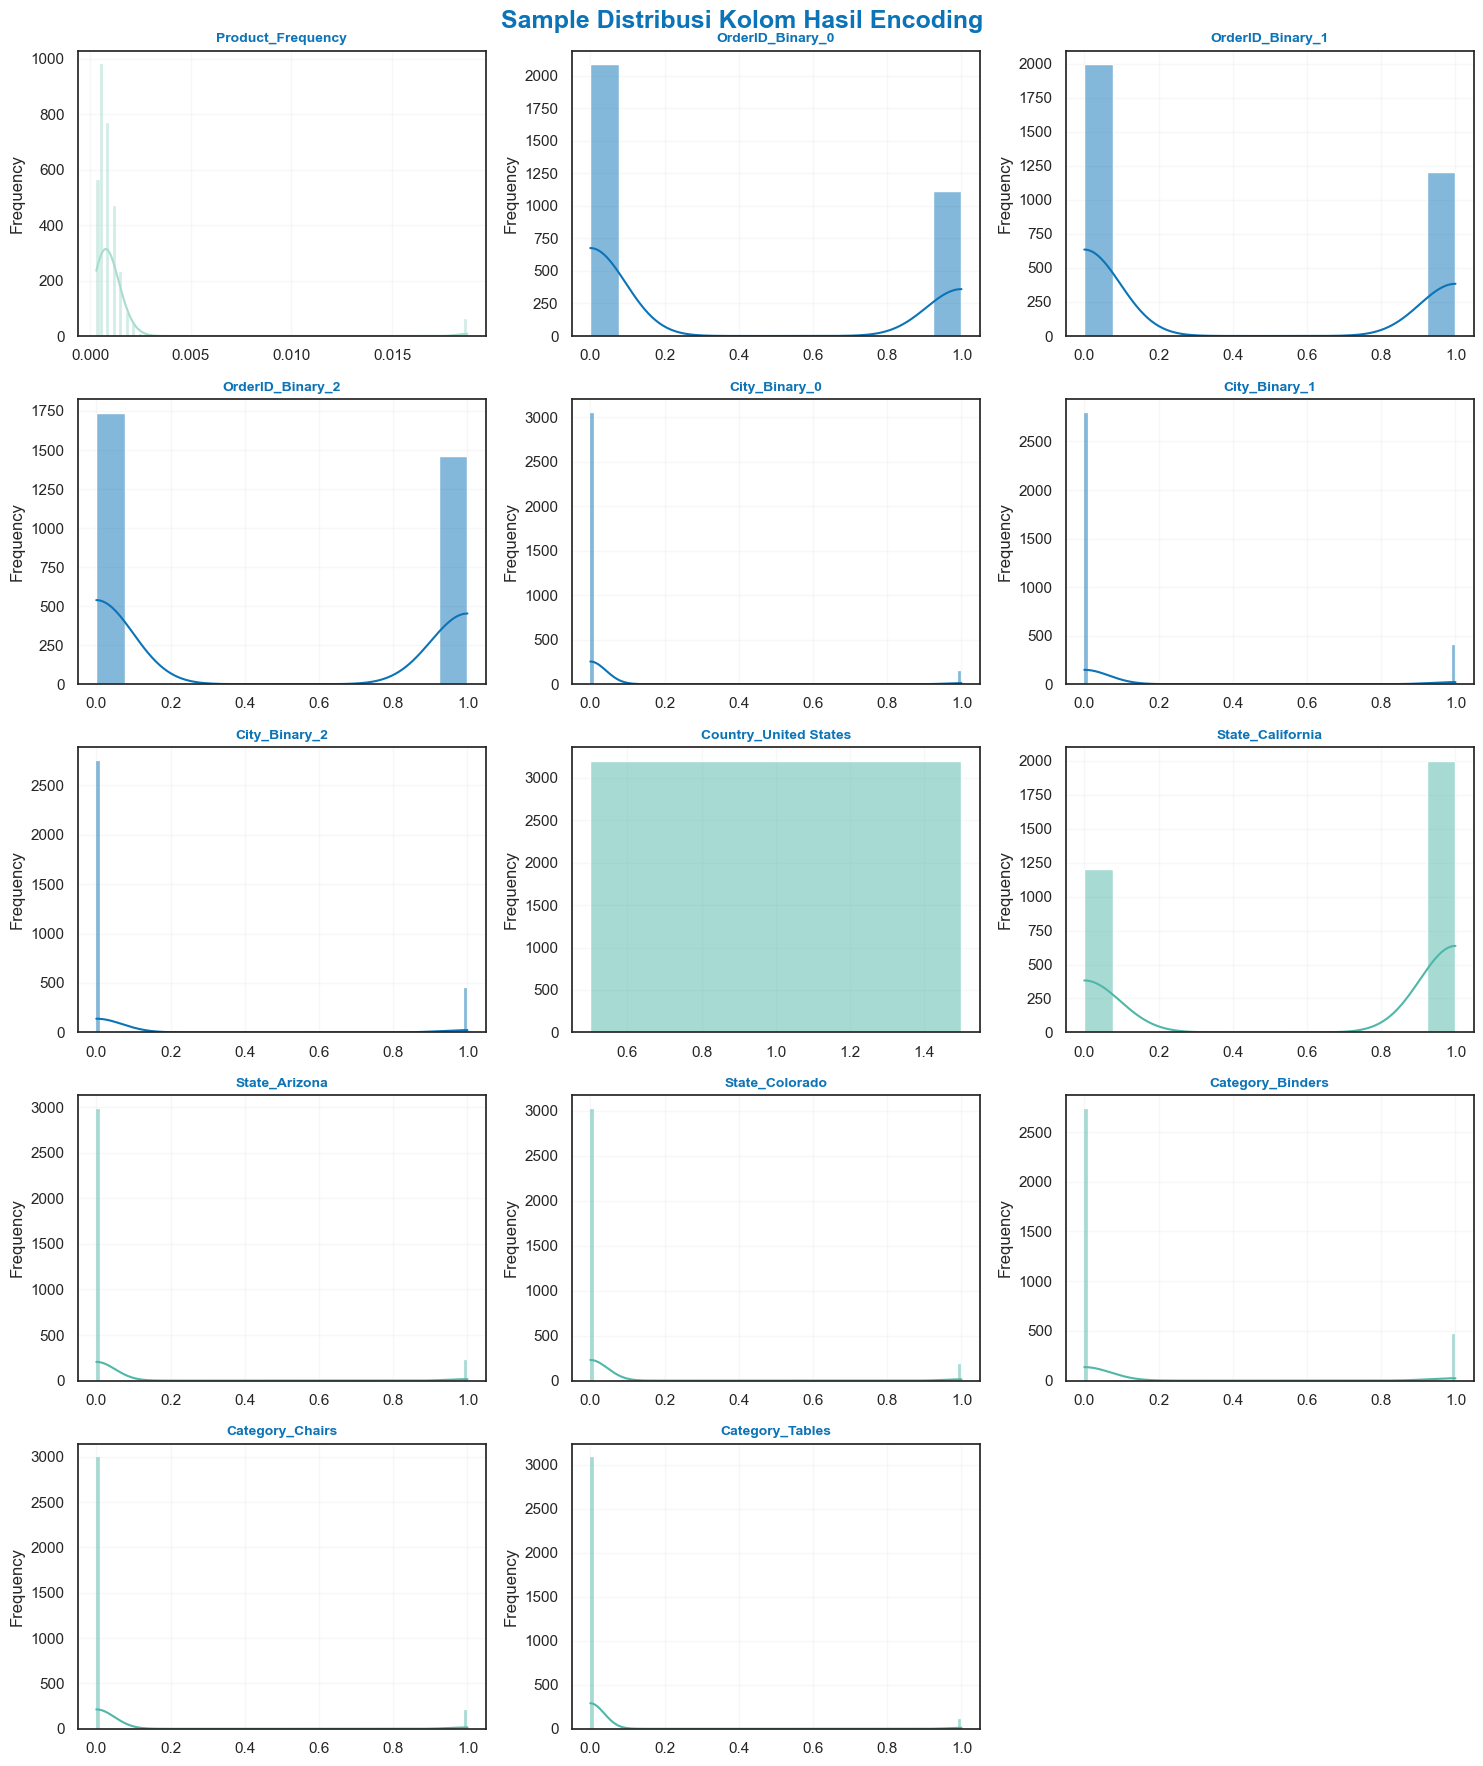

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample kolom hasil encoding
sample_cols = ["Product_Frequency","OrderID_Binary_0","OrderID_Binary_1","OrderID_Binary_2","City_Binary_0","City_Binary_1","City_Binary_2","Country_United States","State_California",
    "State_Arizona","State_Colorado","Category_Binders","Category_Chairs","Category_Tables"]

sns.set_theme(style="white")

# Subplot
fig, axes = plt.subplots(5,3,figsize=(15,18))

axes = axes.flatten()

for i, col in enumerate(sample_cols):

    # Warna sesuai encoding
    if col.startswith("OrderID_Binary") or col.startswith("City_Binary"):
        color = "#0B73B7"   # biru

    elif col.startswith("Country_") or col.startswith("State_") or col.startswith("Category_"):
        color = "#4FB7A8"   # hijau tosca

    else:
        color = "#A7DCCF"   # mint

    sns.histplot(data=df_rf_encoding,x=col,kde=True,color=color,ax=axes[i])

    axes[i].set_title(col,fontsize=10,fontweight="bold",color="#0B73B7")

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(alpha=0.15)

# Hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Sample Distribusi Kolom Hasil Encoding",fontsize=18,fontweight="bold",color="#0B73B7")

plt.tight_layout()
plt.show()

# Final Output

In [44]:
# Final Output
# Membuat dataset akhir setelah seluruh proses preprocessing dan encoding selesai dilakukan.

final_df_rf = df_rf_encoding.copy()

# Menampilkan informasi dataset akhir
final_df_rf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 63 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Order ID               3203 non-null   object        
 1   OrderID_Binary_0       3203 non-null   int64         
 2   OrderID_Binary_1       3203 non-null   int64         
 3   OrderID_Binary_2       3203 non-null   int64         
 4   OrderID_Binary_3       3203 non-null   int64         
 5   OrderID_Binary_4       3203 non-null   int64         
 6   OrderID_Binary_5       3203 non-null   int64         
 7   OrderID_Binary_6       3203 non-null   int64         
 8   OrderID_Binary_7       3203 non-null   int64         
 9   OrderID_Binary_8       3203 non-null   int64         
 10  OrderID_Binary_9       3203 non-null   int64         
 11  OrderID_Binary_10      3203 non-null   int64         
 12  Order Date             3203 non-null   datetime64[ns]
 13  Shi

In [45]:
# Menampilkan ukuran dataset akhir
row, col = final_df_rf.shape
print(f"Terdapat {row} Baris dan {col} Kolom")

Terdapat 3203 Baris dan 63 Kolom


In [46]:
# Menampilkan 5 data pertama dataset akhir
final_df_rf.head(3)

,Order ID,OrderID_Binary_0,OrderID_Binary_1,OrderID_Binary_2,OrderID_Binary_3,OrderID_Binary_4,OrderID_Binary_5,OrderID_Binary_6,OrderID_Binary_7,OrderID_Binary_8,...,Category_Storage,Category_Supplies,Category_Tables,Product Name,Product_Frequency,Sales,Quantity,Profit,HPP,Total Sales
0,CA-2013-138688,0,0,0,0,0,0,0,0,0,...,0,0,0,self-adhesive address labels for typewriters b...,0.000937,14.62,2,6.87,7.75,29.24
1,CA-2011-115812,0,0,0,0,0,0,0,0,0,...,0,0,0,eldon expressions wood and plastic desk access...,0.000937,48.86,7,14.17,34.69,342.02
2,CA-2011-115812,0,0,0,0,0,0,0,0,0,...,0,0,0,newell 322,0.000312,7.28,4,1.97,5.31,29.12


# EXPLORATORY DATA ANALYSIS (EDA)

## Reading & Extracting Data

In [47]:
df_eda = df_rf_manipulation2.copy()
df_eda.head(5)

,Order ID,Order Date,Ship Date,EmailID,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,United States,Los Angeles,California,Labels,self-adhesive address labels for typewriters b...,14.62,2,6.87,7.75,29.24
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Furnishings,eldon expressions wood and plastic desk access...,48.86,7,14.17,34.69,342.02
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Art,newell 322,7.28,4,1.97,5.31,29.12
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Phones,mitel 5320 ip phone voip phone,907.15,4,90.72,816.43,3628.60
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Binders,dxl angle-view binders with locking rings by s...,18.50,3,5.78,12.72,55.50


In [48]:
print("===== INFO DATAFRAME =====")
df_eda.info()

===== INFO DATAFRAME =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   object        
 1   Order Date    3203 non-null   datetime64[ns]
 2   Ship Date     3203 non-null   datetime64[ns]
 3   EmailID       3203 non-null   object        
 4   Country       3203 non-null   object        
 5   City          3203 non-null   object        
 6   State         3203 non-null   object        
 7   Category      3203 non-null   object        
 8   Product Name  3203 non-null   object        
 9   Sales         3203 non-null   float64       
 10  Quantity      3203 non-null   int64         
 11  Profit        3203 non-null   float64       
 12  HPP           3203 non-null   float64       
 13  Total Sales   3203 non-null   float64       
dtypes: datetime64[ns](2), float64(4), int64(1), object(7)
memory 

In [49]:
df_eda.dtypes

Order ID                object
Order Date      datetime64[ns]
Ship Date       datetime64[ns]
EmailID                 object
Country                 object
City                    object
State                   object
Category                object
Product Name            object
Sales                  float64
Quantity                 int64
Profit                 float64
HPP                    float64
Total Sales            float64
dtype: object

In [50]:
print("\n===== DESCRIPTIVE STATISTICS =====")
df_eda.drop(columns=["Order Date", "Ship Date"]).describe().round(2)


===== DESCRIPTIVE STATISTICS =====


,Sales,Quantity,Profit,HPP,Total Sales
count,3203.00,3203.00,3203.00,3203.00,3203.00
mean,226.49,3.83,33.85,192.64,1121.89
std,524.88,2.26,174.11,432.98,3135.85
min,0.99,1.00,-3399.98,0.55,0.99
25%,19.44,2.00,3.85,12.71,56.75
50%,60.84,3.00,11.17,43.77,206.08
75%,215.81,5.00,33.00,183.58,799.84
max,13999.96,14.00,6719.98,7860.14,55999.84


In [51]:
print("\n===== DESCRIPTIVE STATISTIC - CATEGORICAL =====")
df_rf.describe(include="object")


===== DESCRIPTIVE STATISTIC - CATEGORICAL =====


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name
count,3203,3203,3203,3203,3203,3203,3203
unique,1611,845,911,686,170,17,1494
top,CA-2013-165330,12/3/2014,12/7/2014,WilliamBrown@gmail.com,"United States,Los Angeles,California",Binders,Staples
freq,11,19,27,24,747,471,60


In [52]:
# Nilai unik (kategorikal)

cat_cols = df_rf_manipulation2.select_dtypes(include=["object"]).columns

cat_values = []

for col in cat_cols:
    cat_values.append({'column': col,'unique_values': (df_rf_manipulation2[col].dropna().unique().tolist()),'n_unique': (df_rf_manipulation2[col].nunique(dropna=True))})

cat_values_df = pd.DataFrame(cat_values)

pd.set_option('display.max_colwidth', None)

cat_values_df

,column,unique_values,n_unique
0,Order ID,"[CA-2013-138688, CA-2011-115812, CA-2013-161389, CA-2011-167164, CA-2011-143336, CA-2012-106320, CA-2013-121755, CA-2013-101343, CA-2012-135545, CA-2011-106376, CA-2011-139451, CA-2013-109806, US-2014-109484, CA-2014-157833, US-2012-156867, CA-2012-110457, US-2014-107272, US-2013-125969, CA-2013-145583, CA-2014-106180, CA-2012-110744, CA-2013-158834, CA-2012-124919, CA-2012-118948, CA-2011-104269, CA-2013-162733, CA-2013-154508, CA-2013-113817, CA-2011-118962, CA-2011-123260, CA-2012-131457, CA-2011-133690, CA-2014-108329, CA-2013-130162, CA-2014-160514, CA-2013-154739, CA-2013-145625, CA-2012-155040, CA-2014-163979, CA-2012-155334, CA-2014-118136, CA-2012-130890, CA-2012-130883, CA-2011-111451, CA-2013-142902, CA-2011-156601, CA-2013-162138, CA-2012-137946, CA-2011-129924, CA-2012-128167, CA-2014-169901, CA-2011-123344, US-2011-119137, CA-2013-134775, US-2011-135972, CA-2014-102946, CA-2014-117457, CA-2014-142636, CA-2014-122105, CA-2013-148796, CA-2014-110478, CA-2011-142048, US-2011-110674, CA-2012-109638, CA-2013-109869, CA-2011-144666, CA-2013-103891, CA-2011-134677, CA-2014-140963, CA-2013-169166, CA-2013-126158, US-2013-105578, CA-2014-163405, CA-2014-127432, US-2013-139486, CA-2012-102848, US-2014-129441, CA-2013-126613, CA-2013-136924, CA-2013-136406, CA-2014-100650, CA-2013-113243, CA-2014-118731, CA-2012-130736, CA-2014-137099, CA-2014-156951, CA-2013-127250, CA-2012-149713, CA-2012-132906, CA-2014-145233, US-2013-156986, CA-2011-131450, CA-2014-153787, CA-2014-133431, US-2013-135720, US-2013-123470, CA-2013-115917, CA-2014-167913, CA-2013-103947, CA-2013-160745, ...]",1611
1,EmailID,"[DarrinVanHuff@gmail.com, BrosinaHoffman@gmail.com, IreneMaddox@gmail.com, AlejandroGrove@gmail.com, ZuschussDonatelli@gmail.com, EmilyBurns@gmail.com, EricHoffmann@gmail.com, RubenAusman@gmail.com, KunstMiller@gmail.com, BrendanSweed@gmail.com, DuaneNoonan@gmail.com, JimSink@gmail.com, RogerBarcio@gmail.com, KatherineDucich@gmail.com, LenaCacioppo@gmail.com, DaveKipp@gmail.com, TroyStaebel@gmail.com, LindsayShagiari@gmail.com, LenaCreighton@gmail.com, SallyHughsby@gmail.com, HelenAndreada@gmail.com, TamaraWillingham@gmail.com, StephaniePhelps@gmail.com, NeilKnudson@gmail.com, DaveBrooks@gmail.com, TedTrevino@gmail.com, RubenDartt@gmail.com, MaxJones@gmail.com, ChadSievert@gmail.com, FrankMerwin@gmail.com, MaryZewe@gmail.com, BruceStewart@gmail.com, LaurelElliston@gmail.com, JonathanHowell@gmail.com, DavidBremer@gmail.com, LoganHaushalter@gmail.com, KellyCollister@gmail.com, AlanHwang@gmail.com, KristenHastings@gmail.com, BarryBlumstein@gmail.com, JasO'Carroll@gmail.com, TracyBlumstein@gmail.com, KellyLampkin@gmail.com, BenPeterman@gmail.com, FrankAtkinson@gmail.com, GraceKelly@gmail.com, DougBickford@gmail.com, AlyssaCrouse@gmail.com, KenLonsdale@gmail.com, ClayCheatham@gmail.com, JuliaDunbar@gmail.com, ArthurGainer@gmail.com, AlejandroSavely@gmail.com, JackGarza@gmail.com, VictorPreis@gmail.com, KeithHerrera@gmail.com, KimberlyCarter@gmail.com, CarolineJumper@gmail.com, PhilipBrown@gmail.com, SungPak@gmail.com, JoelEaton@gmail.com, SanjitChand@gmail.com, JosephHolt@gmail.com, TanjaNorvell@gmail.com, JeremyPistek@gmail.com, XylonaPreis@gmail.com, MichelleTran@gmail.com, SoniaSunley@gmail.com, MaribethYedwab@gmail.com, BradleyNguyen@gmail.com, AlanDominguez@gmail.com, KarenBern@gmail.com, JasperCacioppo@gmail.com, AllenArmold@gmail.com, ErinSmith@gmail.com, BillDonatelli@gmail.com, DeanKatz@gmail.com, OlveraToch@gmail.com, LizPelletier@gmail.com, JeremyFarry@gmail.com, FrankPreis@gmail.com, EllisBallard@gmail.com, SarahFoster@gmail.com, TrudyGlocke@gmail.com, CharlesCrestani@gmail.com, DiannaVittorini@gmail.com, ZuschussCarroll@gmail.com, LenaRadford@gmail.com, AnnieThurman@gmail.com, LoganCurrie@gmail.com, FredMcMath@gmail.com, MaxEngle@gmail.com, RickBensley@gmail.com, JohnLee@gmail.com, AnthonyRawles@gmail.com, AlanBarnes@gmail.com, JayKimmel@gmail.com, Dorrisliebe@gmail.com, ChristineKarga

In [53]:
# Proporsi data category 

cat_cols = df_rf_manipulation2.select_dtypes(include=["object"]).columns

for col in cat_cols:
    print(f"\nDistribusi {col}")
    print(df_rf_manipulation2[col].value_counts(dropna=False,normalize=False).round(3))


Distribusi Order ID
Order ID
CA-2013-165330    11
CA-2011-106439     9
CA-2012-104346     9
CA-2012-164882     9
CA-2014-117457     9
                  ..
CA-2014-123701     1
US-2011-167262     1
CA-2014-108091     1
CA-2012-144722     1
CA-2014-119914     1
Name: count, Length: 1611, dtype: int64

Distribusi EmailID
EmailID
WilliamBrown@gmail.com       24
ArthurPrichep@gmail.com      23
RickWilson@gmail.com         19
GregGuthrie@gmail.com        17
ZuschussCarroll@gmail.com    16
                             ..
RossDeVincentis@gmail.com     1
BenjaminVenier@gmail.com      1
NickRadford@gmail.com         1
MonicaFederle@gmail.com       1
VictorPreis@gmail.com         1
Name: count, Length: 686, dtype: int64

Distribusi Country
Country
United States    3203
Name: count, dtype: int64

Distribusi City
City
Los Angeles       747
San Francisco     510
Seattle           428
San Diego         170
Phoenix            63
                 ... 
Cheyenne            1
Yucaipa             1
Reddin

In [54]:
row, col = df_rf_manipulation2.shape
print(f"Terdapat {row} Baris dan {col} Kolom")

Terdapat 3203 Baris dan 14 Kolom


In [55]:
# Melakukan pengecekan duplicate data dan missing values
# untuk mengetahui kualitas data sebelum dilakukan preprocessing lebih lanjut.

# Mengecek jumlah data duplikat
duplicate_checking = df_eda.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_checking}")

# Mengecek jumlah missing values pada setiap kolom
missing_values_checking = df_eda.isnull().sum()
print("\nJumlah missing values pada setiap kolom:")
print(missing_values_checking)

Jumlah data duplikat: 0

Jumlah missing values pada setiap kolom:
Order ID        0
Order Date      0
Ship Date       0
EmailID         0
Country         0
City            0
State           0
Category        0
Product Name    0
Sales           0
Quantity        0
Profit          0
HPP             0
Total Sales     0
dtype: int64


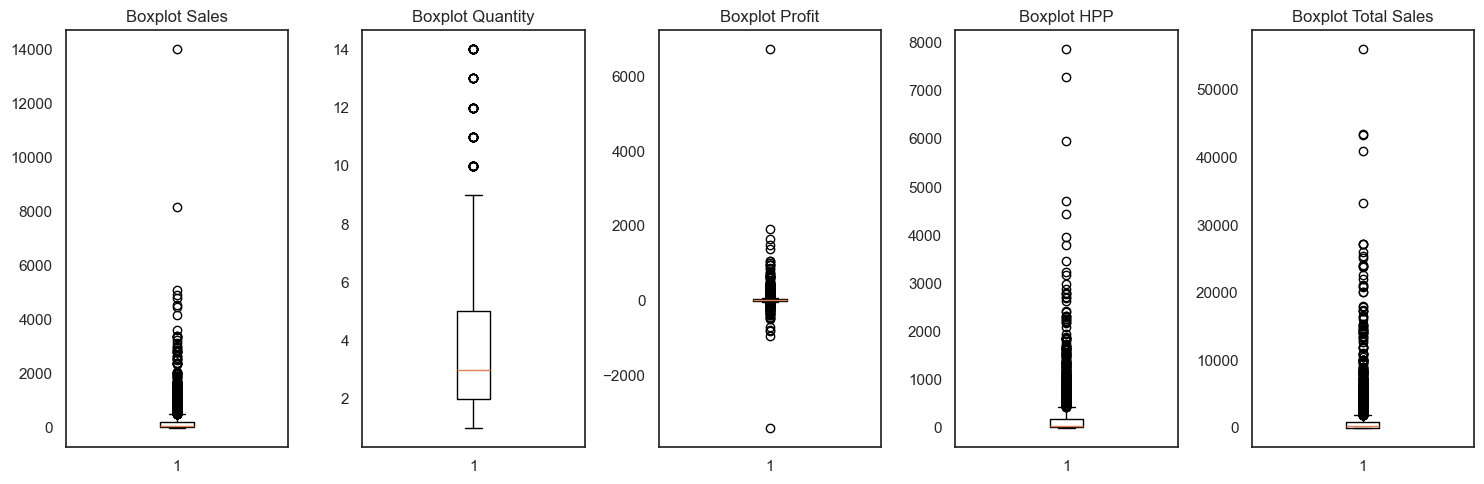

In [56]:
# Melakukan visualisasi boxplot pada atribut numerik
# untuk mengidentifikasi potensi outlier pada data.

import matplotlib.pyplot as plt

# Daftar kolom numerik
num_cols = ["Sales","Quantity","Profit","HPP","Total Sales"]

plt.figure(figsize=(15,5))

for i, col in enumerate(num_cols, 1):

    plt.subplot(1, len(num_cols), i)
    plt.boxplot(df_eda[col])
    plt.title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

In [57]:
# Evaluasi jumlah dan persentase outlier pada seluruh atribut numerik menggunakan metode IQR.

out_cols = ["Sales","Quantity","Profit","HPP","Total Sales"]

for col in out_cols:

    # Menghitung IQR
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1

    # Menentukan batas bawah dan atas
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Mengidentifikasi outlier
    outlier = df_eda[(df_eda[col] < lower_bound) |(df_eda[col] > upper_bound)]

    # Menghitung jumlah dan persentase
    jumlah_outlier = len(outlier)
    persentase_outlier = (jumlah_outlier / len(df_eda)) * 100

    # Menampilkan hasil
    print(f"\n{col}")
    print(f"Jumlah outlier      : {jumlah_outlier}")
    print(f"Persentase outlier  : {persentase_outlier:.2f}%")

outlier.head(5)


Sales
Jumlah outlier      : 368
Persentase outlier  : 11.49%

Quantity
Jumlah outlier      : 62
Persentase outlier  : 1.94%

Profit
Jumlah outlier      : 465
Persentase outlier  : 14.52%

HPP
Jumlah outlier      : 387
Persentase outlier  : 12.08%

Total Sales
Jumlah outlier      : 428
Persentase outlier  : 13.36%


,Order ID,Order Date,Ship Date,EmailID,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Phones,mitel 5320 ip phone voip phone,907.15,4,90.72,816.43,3628.60
6,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Tables,chromcraft rectangular conference tables,1706.18,9,85.31,1620.87,15355.62
7,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,United States,Los Angeles,California,Phones,konftel 250 conferenceâ phoneâ - charcoal black,911.42,4,68.36,843.06,3645.68
13,CA-2012-106320,2012-09-25,2012-09-30,EmilyBurns@gmail.com,United States,Orem,Utah,Tables,bretford cr4500 series slim rectangular table,1044.63,3,240.26,804.37,3133.89
21,CA-2011-106376,2011-12-05,2011-12-10,BrendanSweed@gmail.com,United States,Gilbert,Arizona,Art,"hunt boston model 1606 high-volume electric pencil sharpener, beige",1113.02,8,111.30,1001.72,8904.16


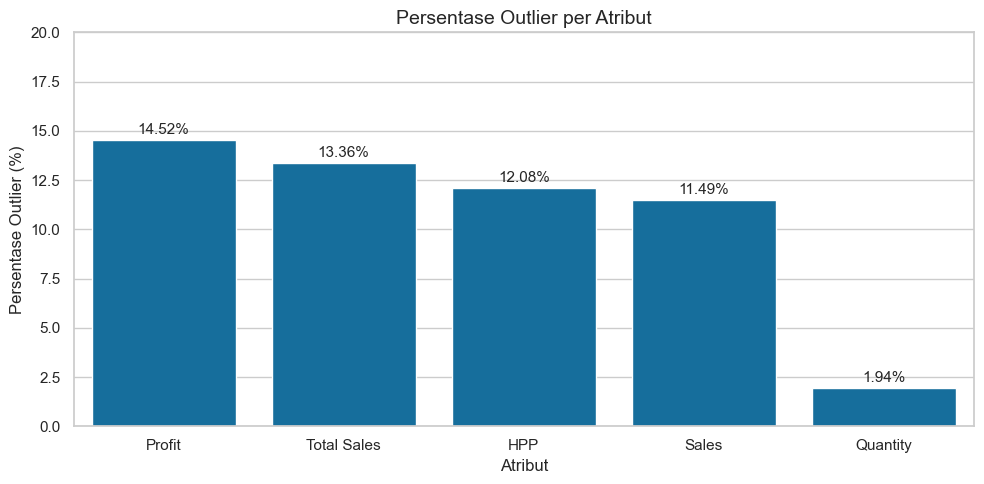

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

outlier_percentage = {
    "Profit": 14.52,
    "Total Sales": 13.36,
    "HPP": 12.08,
    "Sales": 11.49,
    "Quantity": 1.94,
}

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(x=list(outlier_percentage.keys()),y=list(outlier_percentage.values()),color="#0075b2",ax=ax)

ax.set_title("Persentase Outlier per Atribut", fontsize=14)
ax.set_xlabel("Atribut", fontsize=12)
ax.set_ylabel("Persentase Outlier (%)", fontsize=12)
ax.set_ylim(0, 20)

for i, (k, v) in enumerate(outlier_percentage.items()):
    ax.text(i, v + 0.3, f"{v}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

**Keputusan:** 

Outlier tidak dihapus karena merepresentasikan transaksi nyata (bukan kesalahan input data). Nilai ekstrem pada Sales, Profit, HPP, Total Sales, dan Quantity kemungkinan berasal dari produk premium, transaksi bernilai tinggi, atau pesanan dalam jumlah besar yang masih valid secara bisnis. Oleh karena itu, data tetap dipertahankan.

## Fundamentals Visualization

In [59]:
# Import library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mengatur style visualisasi
sns.set_style("whitegrid")

# Warna turunan biru-hijau
colors = ["#004e64","#0077b6","#2a9d8f","#52b69a","#95d5b2"]

#### Histogram Distribusi atribut numerik

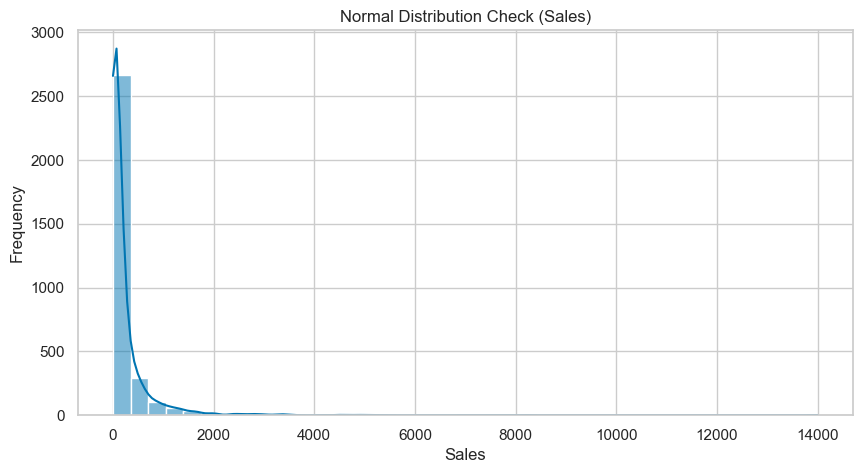

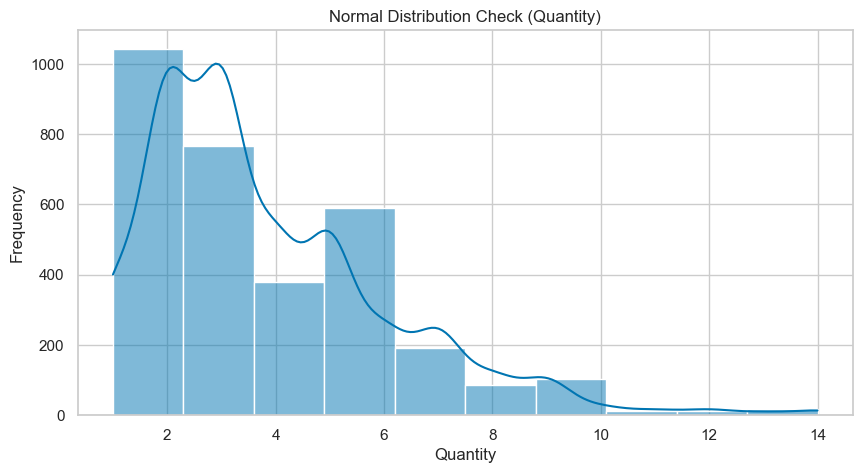

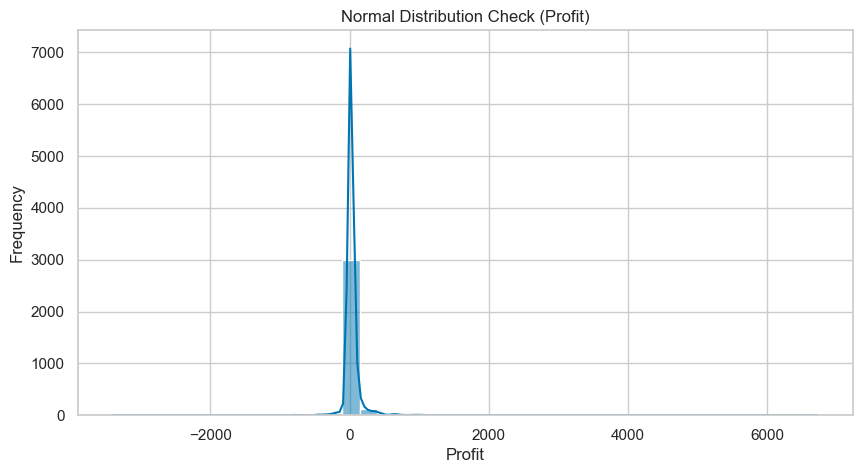

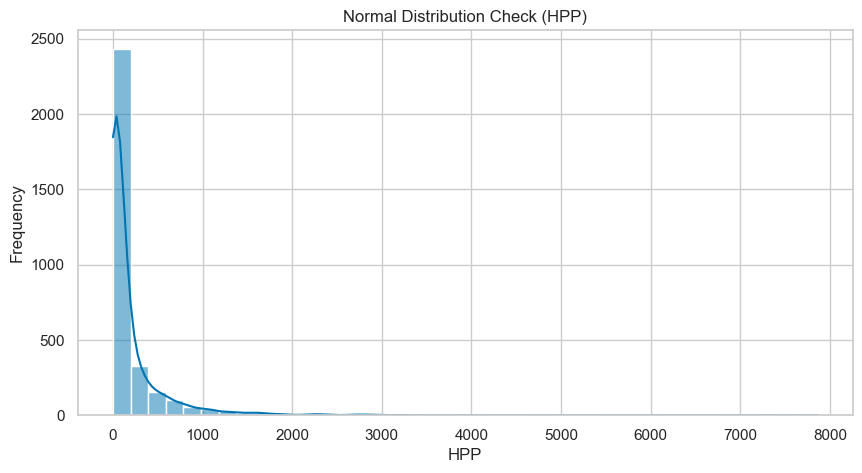

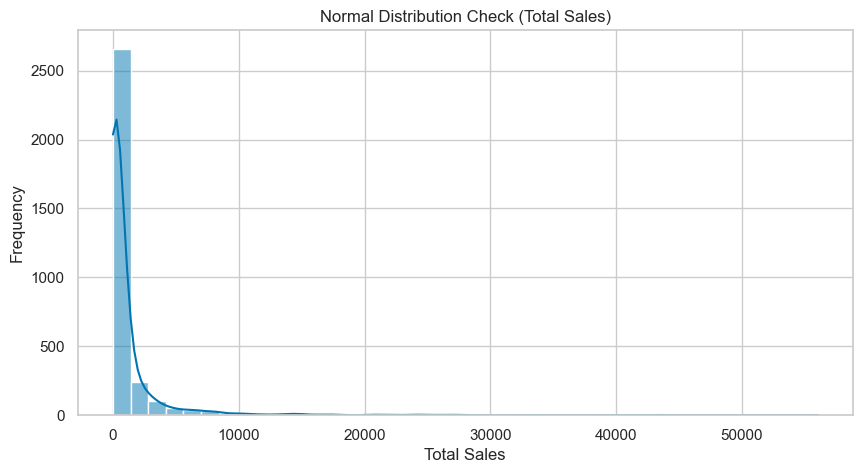

In [60]:
# Fundamentals Visualization 1
# Membuat histogram untuk melihat distribusi
# seluruh atribut numerikal.

import seaborn as sns
import matplotlib.pyplot as plt

# Bins per kolom
kolom_bins = {"Sales": 40,"Quantity": 10,"Profit": 40,"HPP": 40,"Total Sales": 40}

for kolom, bins in kolom_bins.items():

    plt.figure(figsize=(10,5))

    sns.histplot(df_eda[kolom],bins=bins,kde=True,color="#0075b2")

    plt.title(f"Normal Distribution Check ({kolom})")

    plt.xlabel(kolom)
    plt.ylabel("Frequency")

    plt.show()

**Interpretasi:**

Berdasarkan visualisasi histogram dan KDE, atribut numerik seperti Profit, HPP, dan Total Sales menunjukkan pola distribusi yang tidak normal (non-normal distribution) dan cenderung right-skewed (miring ke kanan). Sebagian besar data terkonsentrasi pada nilai yang relatif rendah, sementara terdapat sejumlah kecil observasi dengan nilai yang sangat tinggi sehingga membentuk ekor distribusi yang panjang di sisi kanan. Pada atribut Profit, juga terlihat adanya nilai negatif yang mengindikasikan transaksi mengalami kerugian. Pola distribusi ini menunjukkan adanya ketidakseimbangan persebaran data serta indikasi outlier, sehingga karakteristik data perlu diperhatikan pada tahap analisis dan preprocessing selanjutnya.

#### Bar Chart Total Sales Per State

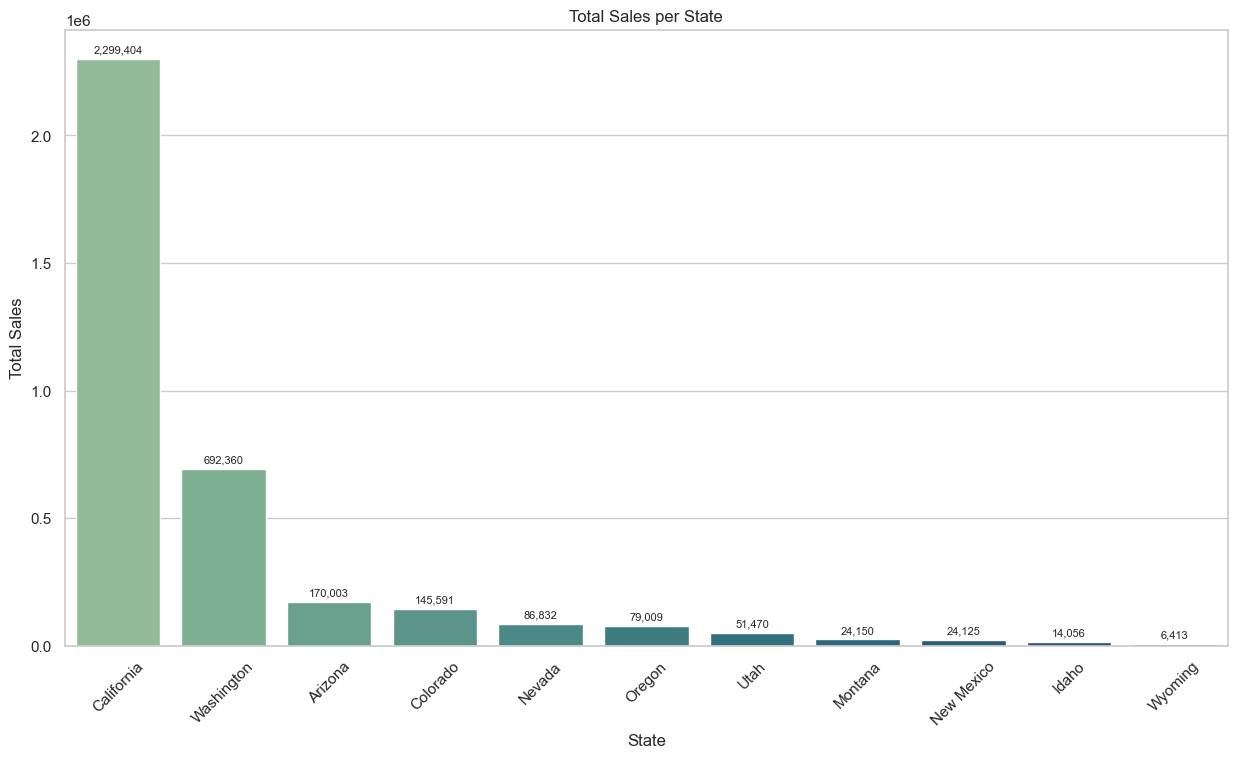

In [61]:
# Fundamentals Visualization 2
# Membuat bar chart total sales per state.

total_sales_state = (df_eda.groupby("State")["Total Sales"].sum().sort_values(ascending=False).reset_index())

plt.figure(figsize=(15,8))
ax = sns.barplot(data=total_sales_state,x="State",y="Total Sales",hue="State",palette="crest",legend=False)

# Menambahkan label pada bar
for container in ax.containers:
    labels = [f'{v.get_height():,.0f}'if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container,labels=labels,padding=3,fontsize=8)

plt.title("Total Sales per State")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

**Interpretasi:**

Total sales paling besar berasal dari California, jauh melampaui state lainnya. Washington menjadi kontributor terbesar kedua, sedangkan beberapa state seperti Idaho dan Wyoming memiliki penjualan yang jauh lebih rendah. Hal ini mengindikasikan bahwa pasar Amazon tidak terdistribusi merata secara geografis. State dengan total sales tertinggi menjadi kontributor utama pendapatan dan perlu mendapat perhatian lebih dalam strategi pemasaran.

#### Scatter Plot Sales vs Profit

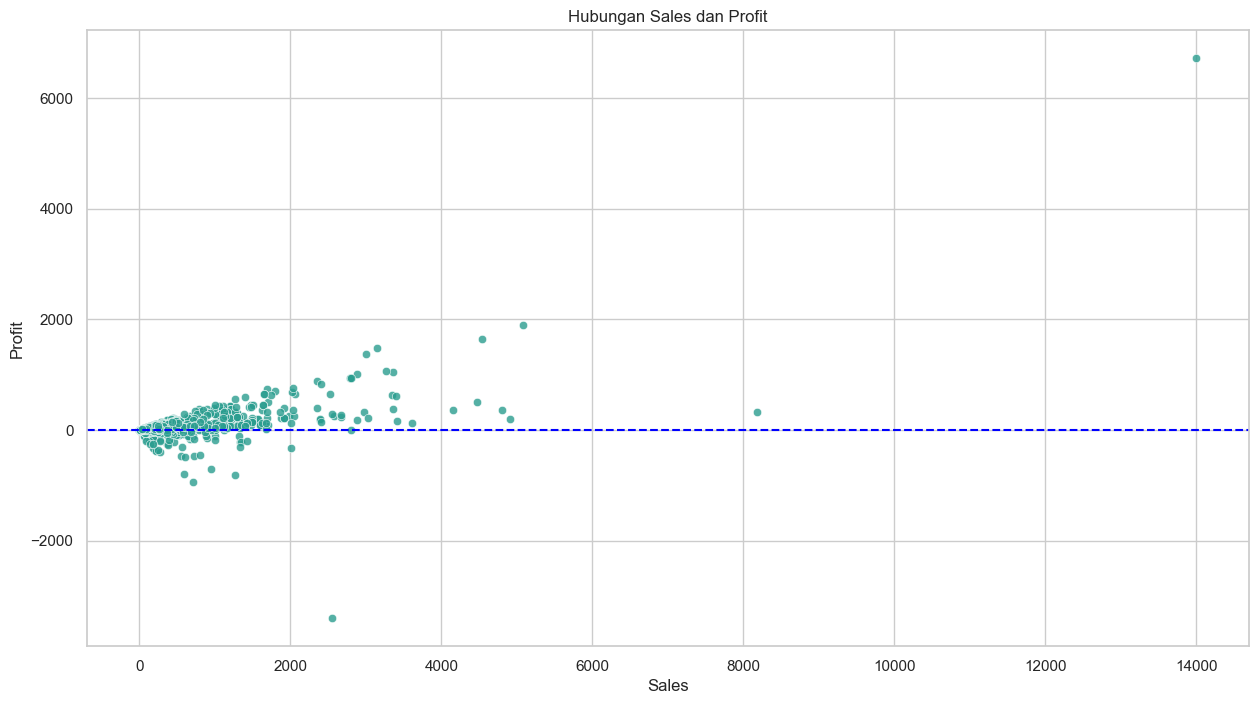

In [62]:
# Fundamentals Visualization 3
# Membuat scatter plot untuk melihat hubungan antara sales dan profit.

plt.figure(figsize=(15,8))

sns.scatterplot(data=df_eda,x="Sales",y="Profit",color=colors[2],alpha=0.8)

plt.axhline(y=0,color="blue",linestyle="--")

plt.title("Hubungan Sales dan Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

**Interpretasi:**

Secara umum, semakin tinggi sales (harga jual) maka profit juga cenderung meningkat. Namun, tidak semua penjualan tinggi menghasilkan profit besar karena masih ada beberapa transaksi dengan sales tinggi tetapi profit rendah atau bahkan rugi. Hal ini menunjukkan bahwa besarnya harga jual belum tentu selalu sebanding dengan keuntungan yang diperoleh.

#### Line Chart Tren Total Sales Pertahun

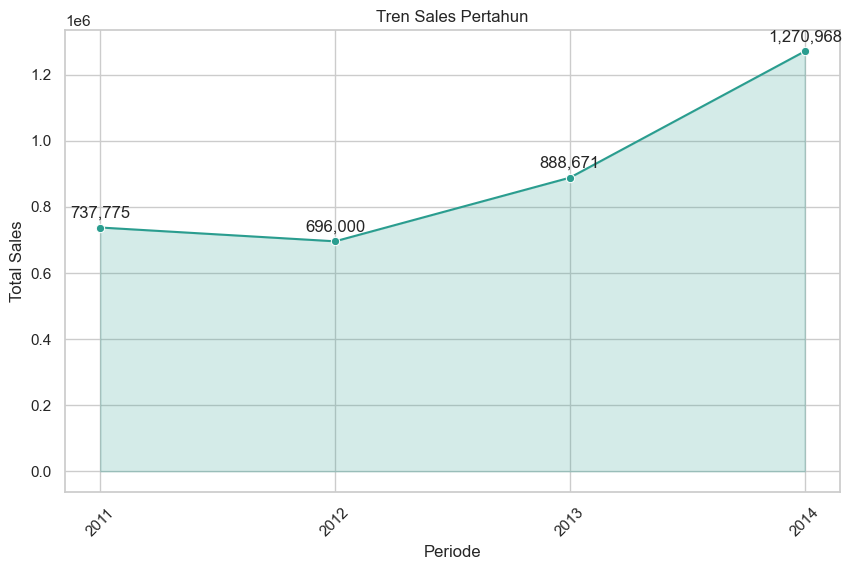

In [63]:
# Fundamentals Visualization 4
# Membuat line chart untuk melihat tren Total sales pertahun.

plt.figure(figsize=(10,6))

# Mengambil tahun dari Order Date
Yearly_sales = (df_eda.groupby(df_eda["Order Date"].dt.to_period("Y"))["Total Sales"].sum().reset_index())

# Mengubah format periode menjadi string
Yearly_sales["Order Date"] = (Yearly_sales["Order Date"].astype(str))

# Area fill
plt.fill_between(Yearly_sales["Order Date"],Yearly_sales["Total Sales"],color=colors[2],alpha=0.2)

sns.lineplot(data=Yearly_sales,x="Order Date",y="Total Sales",marker="o",color=colors[2])

# Menambahkan label nilai pada titik line chart
for x, y in zip(Yearly_sales["Order Date"],Yearly_sales["Total Sales"]):
    plt.text(x,y + 30000,f"{y:,.0f}",ha="center")

plt.title("Tren Sales Pertahun")
plt.xlabel("Periode")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

**Interpretasi:**

Total sales menunjukkan tren yang cenderung meningkat dari tahun ke tahun. Setelah mengalami sedikit penurunan pada tahun 2012 dibanding tahun 2011, penjualan kembali meningkat pada tahun 2013 dan mengalami kenaikan yang cukup signifikan pada tahun 2014. Hal ini menunjukkan adanya pertumbuhan performa penjualan perusahaan seiring waktu.

#### Line Chart Tren Profit Pertahun

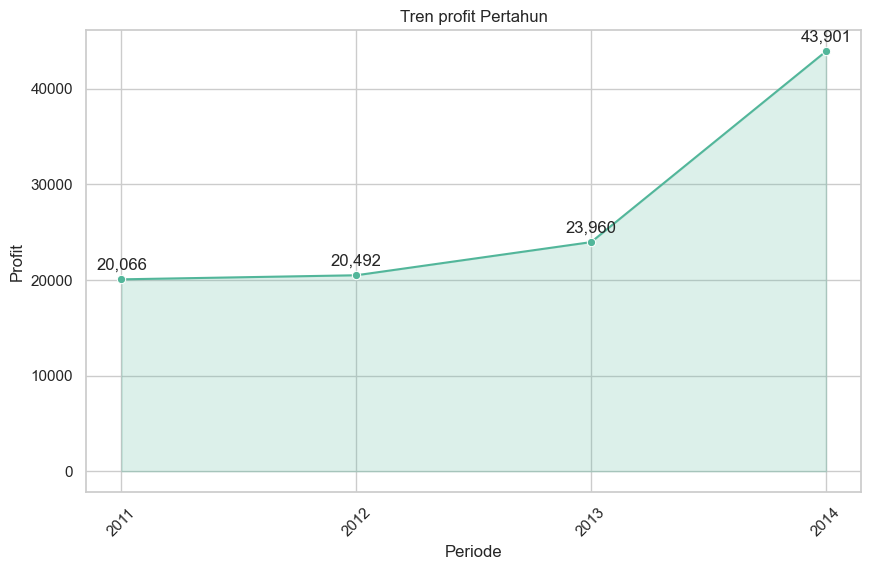

In [64]:
# Fundamentals Visualization 5
# Membuat line chart untuk melihat tren Profit pertahun.

plt.figure(figsize=(10,6))

# Mengambil tahun dari Order Date
Yearly_sales2 = (df_eda.groupby(df_eda["Order Date"].dt.to_period("Y"))["Profit"].sum().reset_index())

# Mengubah format periode menjadi string
Yearly_sales2["Order Date"] = (Yearly_sales2["Order Date"].astype(str))

# Area fill
plt.fill_between(Yearly_sales2["Order Date"],Yearly_sales2["Profit"],color=colors[3],alpha=0.2)

sns.lineplot(data=Yearly_sales2,x="Order Date",y="Profit",marker="o",color=colors[3])

# Menambahkan label nilai pada titik line chart
for x, y in zip(Yearly_sales2["Order Date"],Yearly_sales2["Profit"]):
    plt.text(x,y + 1000,f"{y:,.0f}",ha="center")

plt.title("Tren profit Pertahun")
plt.xlabel("Periode")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

**Interpretasi:**

Tren profit tahunan menunjukkan peningkatan yang relatif konsisten selama periode pengamatan. Profit meningkat secara bertahap dari 2011 hingga 2013, kemudian mengalami kenaikan yang lebih signifikan pada 2014. Kondisi ini menunjukkan bahwa performa keuntungan perusahaan cenderung membaik dari waktu ke waktu.

## Advanced Visualization

#### Heatmap Correlation 

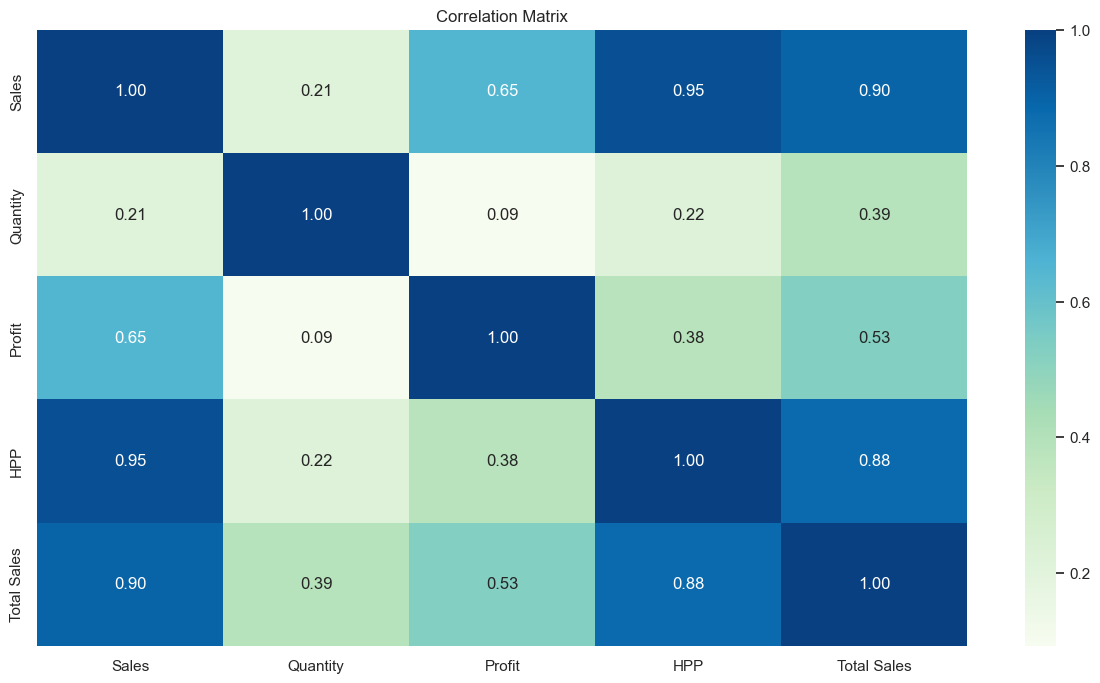

In [65]:
# Advanced Visualization 1
# Membuat heatmap correlation antar variabel numerik.

plt.figure(figsize=(15,8))

sns.heatmap(df_eda[["Sales","Quantity","Profit","HPP","Total Sales"]].corr(),
    annot=True,
    cmap="GnBu",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

**Interpretasi:**

Hubungan kuat antara Sales (harga jual), HPP, dan Total Sales termasuk hal yang wajar karena nilai-nilai tersebut saling berkaitan dalam transaksi. Produk dengan harga jual lebih tinggi biasanya memiliki biaya produksi yang lebih tinggi dan menghasilkan total transaksi yang lebih besar. Namun, profit tidak selalu ikut meningkat karena masih ada kemungkinan biaya yang tinggi atau margin keuntungan yang kecil menyebabkan profit menjadi rendah bahkan minus.

<Figure size 1500x500 with 0 Axes>

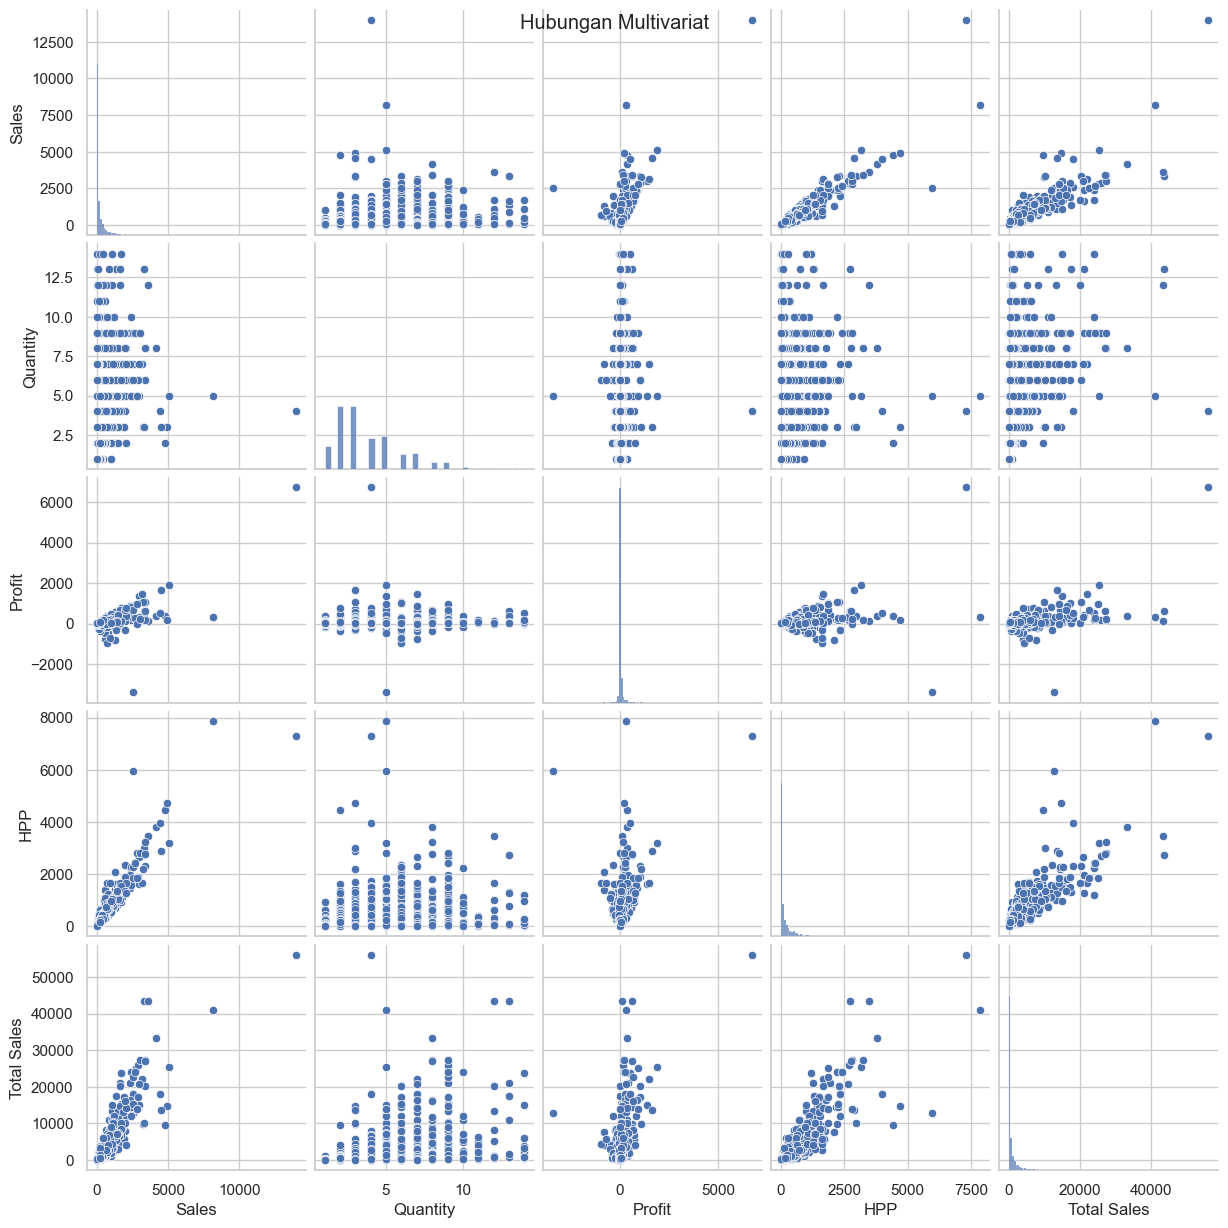

In [66]:
# Advanced Visualization 2
# Membuat pairplot untuk melihat hubungan antar variabel numerik.
plt.figure(figsize=(15,5))
sns.pairplot(df_eda[["Sales","Quantity","Profit","HPP","Total Sales"]])
plt.suptitle("Hubungan Multivariat")

plt.show()

**Interpretasi:**

Secara umum, produk dengan harga jual lebih tinggi cenderung memiliki biaya produksi yang lebih tinggi dan menghasilkan total penjualan yang lebih besar. Namun, profit terlihat lebih bervariasi dan tidak selalu meningkat seiring naiknya harga jual atau total penjualan. Hal ini menunjukkan bahwa besarnya keuntungan kemungkinan juga dipengaruhi oleh faktor lain, seperti biaya produksi dan margin tiap produk.

#### Menggabungkan beberapa grafik dalam satu tampilan (subplot)

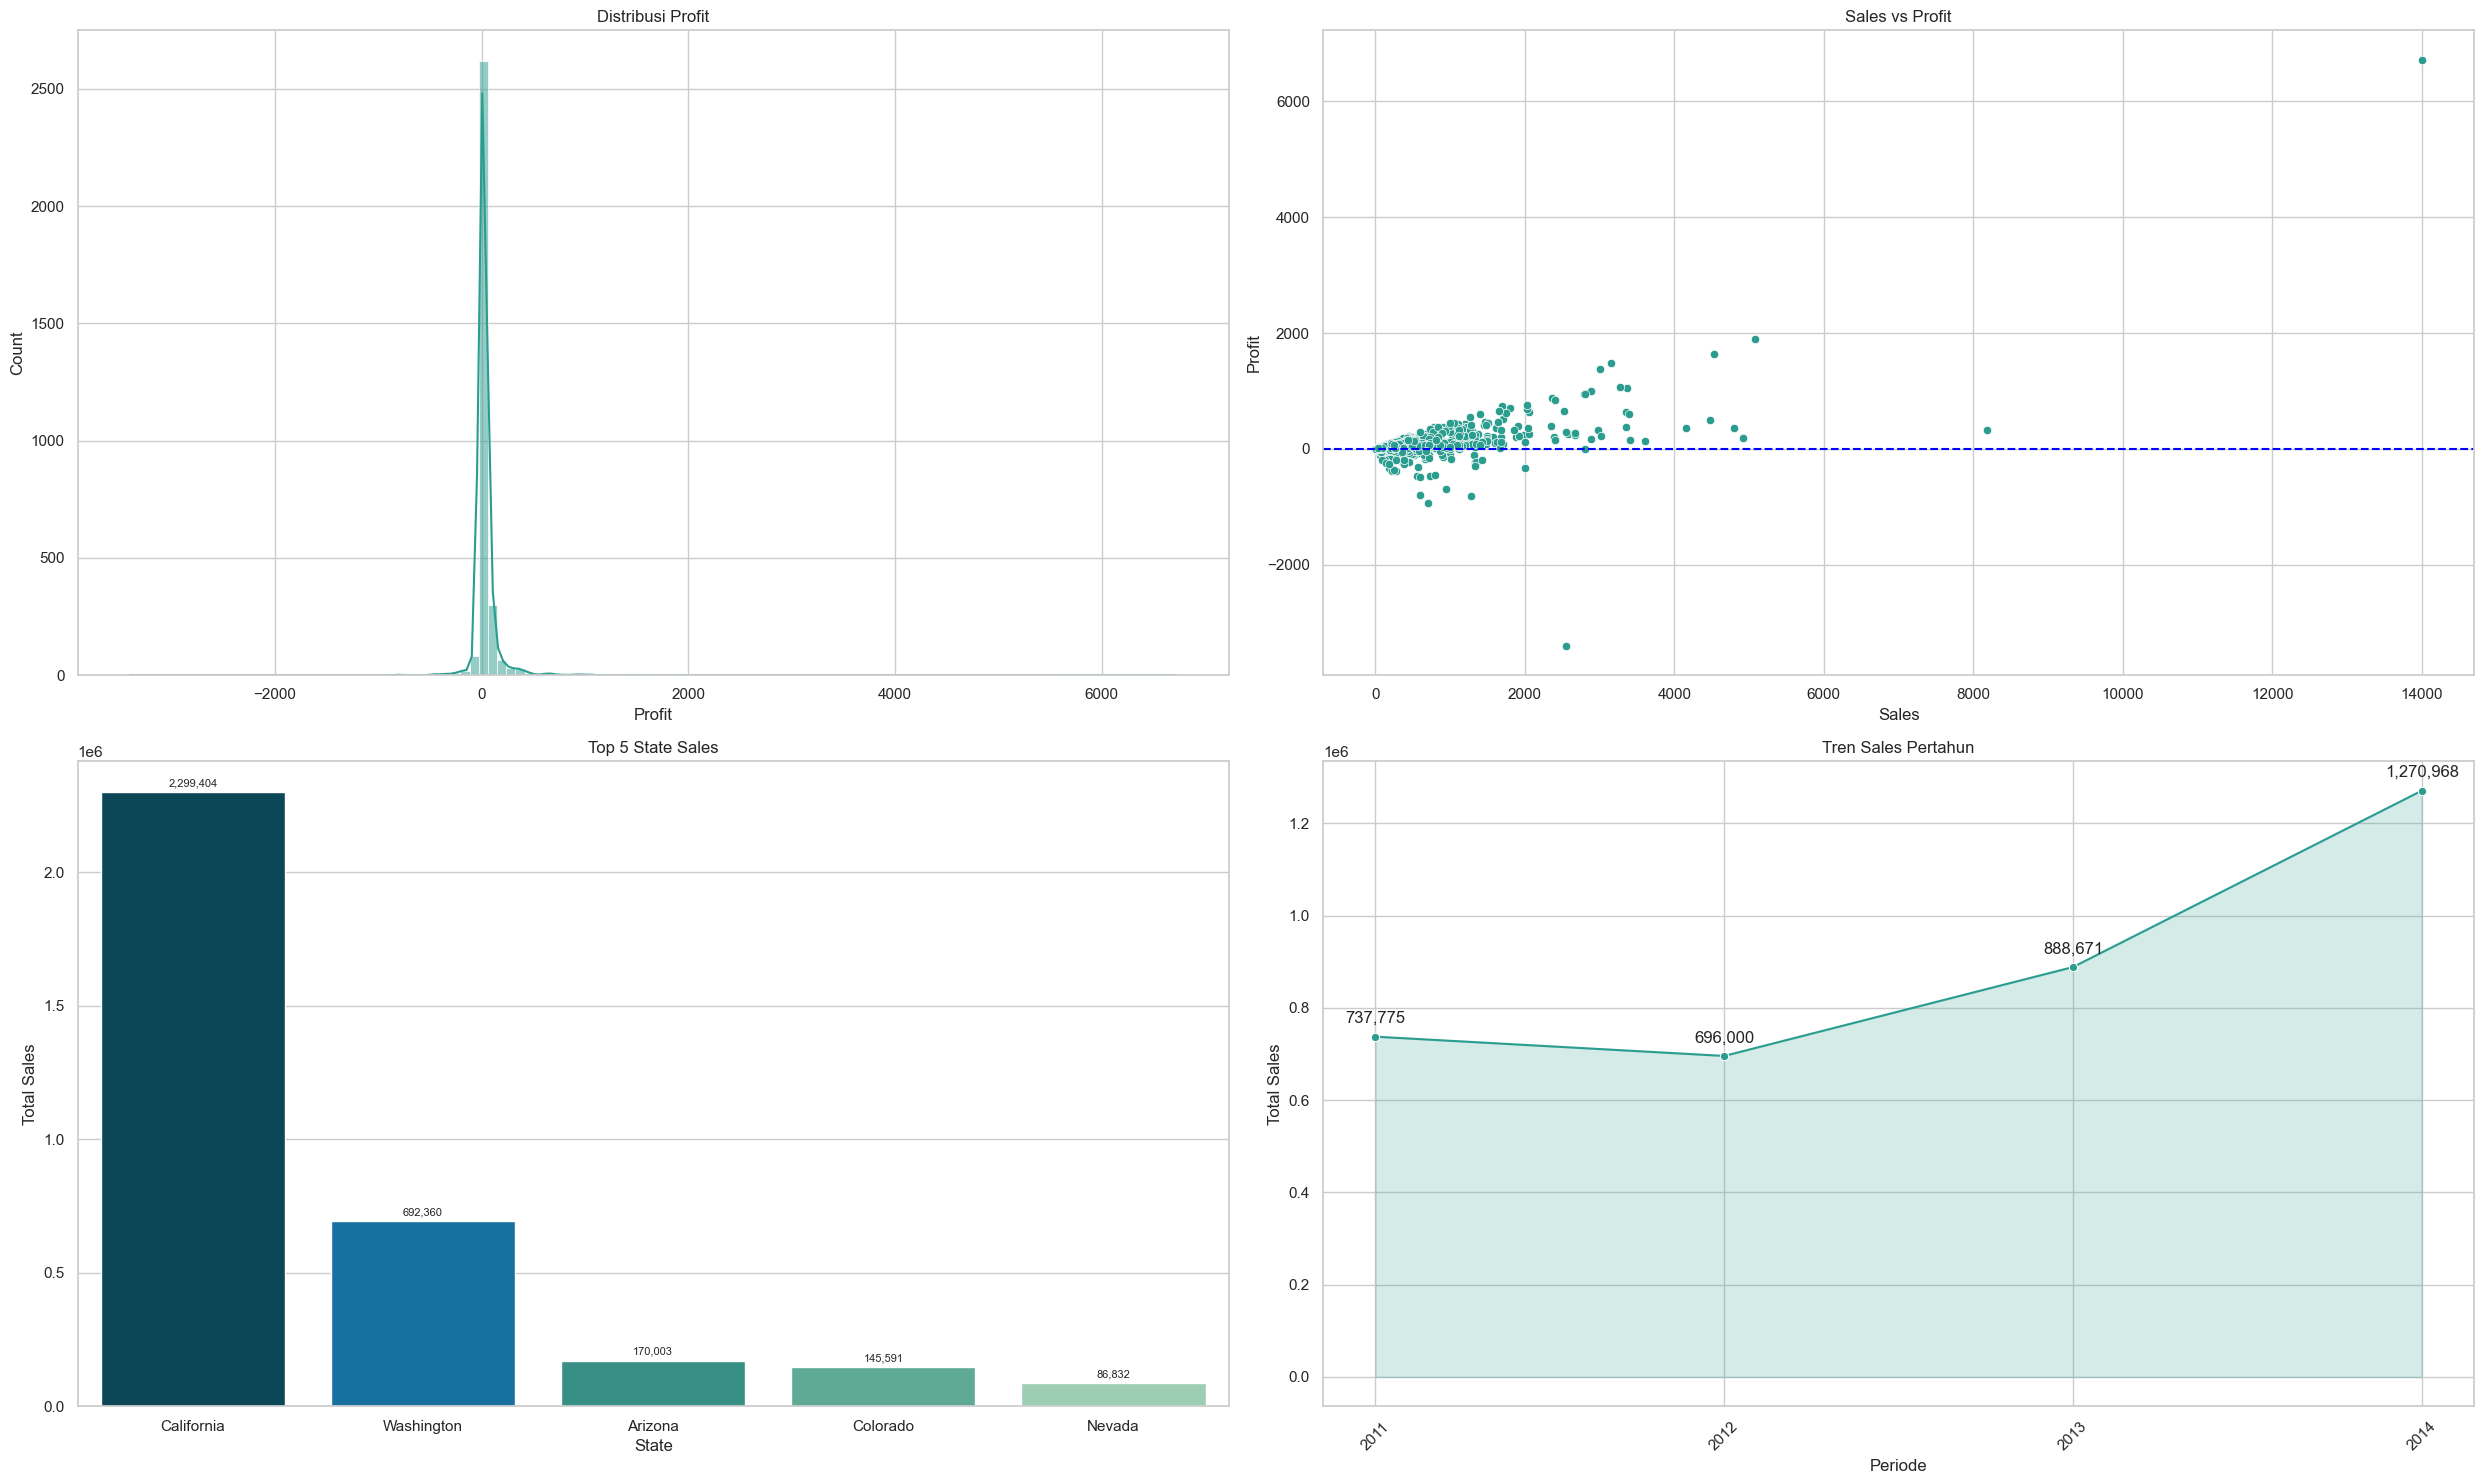

In [67]:
# Advanced Visualization 3
# Menggabungkan beberapa visualisasi dalam satu tampilan.

plt.figure(figsize=(25,15))

# Histogram Profit
plt.subplot(2,2,1)

sns.histplot(df_eda["Profit"],color=colors[2],kde=True)
plt.title("Distribusi Profit")

# Scatter Plot
plt.subplot(2,2,2)

sns.scatterplot(data=df_eda,x="Sales",y="Profit",color=colors[2])
plt.axhline(y=0,color="blue",linestyle="--")
plt.title("Sales vs Profit")

# Bar Chart State
plt.subplot(2,2,3)

lb = sns.barplot(data=total_sales_state.head(5),x="State",y="Total Sales",hue="State",palette=colors)
plt.title("Top 5 State Sales")

# Menambahkan label pada bar
for container in lb.containers:
    labels = [f'{v.get_height():,.0f}'if v.get_height() > 0 else '' for v in container]
    lb.bar_label(container,labels=labels,padding=3,fontsize=8)

# Line Chart Tren Total Sales Pertahun
plt.subplot(2,2,4)

plt.fill_between(Yearly_sales["Order Date"],Yearly_sales["Total Sales"],color=colors[2],alpha=0.2)
sns.lineplot(data=Yearly_sales,x="Order Date",y="Total Sales",marker="o",color=colors[2])

# Menambahkan label nilai pada titik line chart
for x, y in zip(Yearly_sales["Order Date"],Yearly_sales["Total Sales"]):
    plt.text(x,y + 30000,f"{y:,.0f}",ha="center")

plt.title("Tren Sales Pertahun")
plt.xlabel("Periode")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

In [68]:
# Membuat dataset profit minus
df_loss = df_eda[df_eda["Profit"] < 0].copy()

Total_transaksi = df_eda.shape[0]
Jumlah_penjualan_minus = len(df_loss)  # ambil jumlah baris dari df_loss
Persentase_minus = (Jumlah_penjualan_minus / Total_transaksi) * 100

print(f"Jumlah penjualan minus: {Jumlah_penjualan_minus} / {Total_transaksi}")
print(f"Persentase minus: {Persentase_minus:.1f}%")

df_loss.head()

# Dataset difilter hanya untuk transaksi dengan profit minus 
# agar analisis lebih fokus pada faktor penyebab kerugian produk.

Jumlah penjualan minus: 318 / 3203
Persentase minus: 9.9%


,Order ID,Order Date,Ship Date,EmailID,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
28,US-2014-109484,2014-11-07,2014-11-13,RogerBarcio@gmail.com,United States,Portland,Oregon,Binders,flexible leather- look classic collection ring binder,5.68,1,-3.79,9.47,5.68
30,US-2012-156867,2012-11-13,2012-11-17,LenaCacioppo@gmail.com,United States,Aurora,Colorado,Accessories,logitech k350 2.4ghz wireless keyboard,238.90,6,-26.88,265.78,1433.40
31,US-2012-156867,2012-11-13,2012-11-17,LenaCacioppo@gmail.com,United States,Aurora,Colorado,Furnishings,"deflect-o duramat lighweight, studded, beveled mat for low pile carpeting",102.36,3,-3.84,106.20,307.08
32,US-2012-156867,2012-11-13,2012-11-17,LenaCacioppo@gmail.com,United States,Aurora,Colorado,Binders,"avery trapezoid ring binder, 3"" capacity, black, 1040 sheets",36.88,3,-25.82,62.70,110.64
34,US-2014-107272,2014-11-06,2014-11-13,TroyStaebel@gmail.com,United States,Phoenix,Arizona,Binders,"avery durable slant ring binders, no labels",2.39,2,-1.83,4.22,4.78


In [69]:
Total_transaksi = df_eda.shape[0]
Jumlah_penjualan_minus = len(df_loss)  # ambil jumlah baris dari df_loss
Persentase_minus = (Jumlah_penjualan_minus / Total_transaksi) * 100
print(f"Jumlah penjualan minus: {Jumlah_penjualan_minus} / {Total_transaksi}")
print(f"Persentase minus: {Persentase_minus:.2f}%")

Jumlah penjualan minus: 318 / 3203
Persentase minus: 9.93%


### UNIVARIATE ANALYSIS 
#### Histogram Distribusi Profit Minus

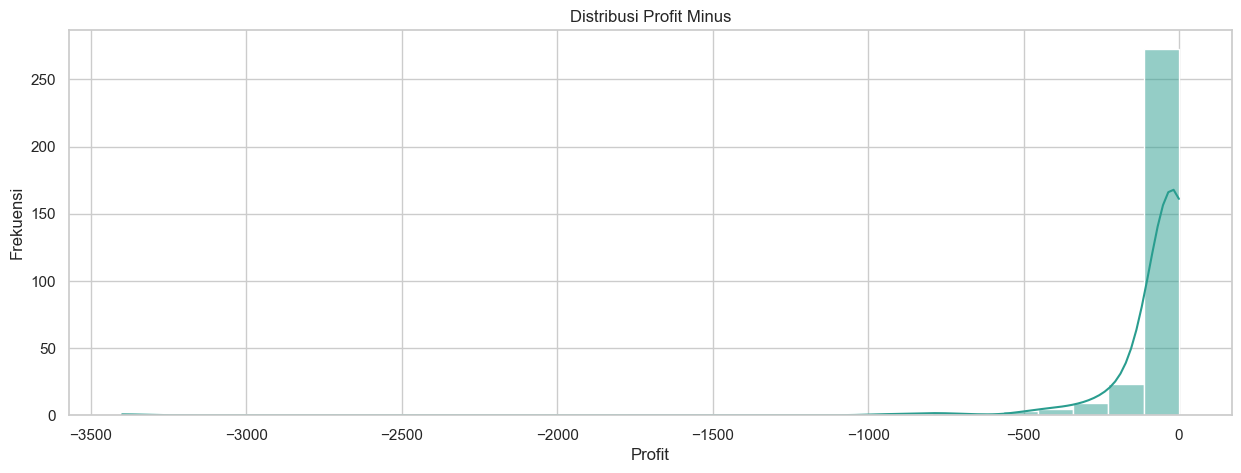

In [70]:
# EDA Univariate 1
# Membuat histogram untuk melihat distribusi profit minus.

plt.figure(figsize=(15,5))

sns.histplot(data=df_loss,x="Profit",bins=30,kde=True,color=colors[2])

plt.title("Distribusi Profit Minus")
plt.xlabel("Profit")
plt.ylabel("Frekuensi")

plt.show()

**Interpretasi:**

Distribusi profit minus menunjukkan bahwa sebagian besar transaksi yang mengalami kerugian berada di dekat angka nol, yang berarti mayoritas kerugian masih tergolong kecil. Namun, terdapat beberapa transaksi dengan kerugian yang jauh lebih besar dibanding transaksi lainnya, terlihat dari distribusi yang memanjang ke sisi kiri (left-skewed). Hal ini menunjukkan bahwa meskipun jumlahnya sedikit, terdapat beberapa transaksi yang memberikan dampak kerugian cukup signifikan terhadap perusahaan.

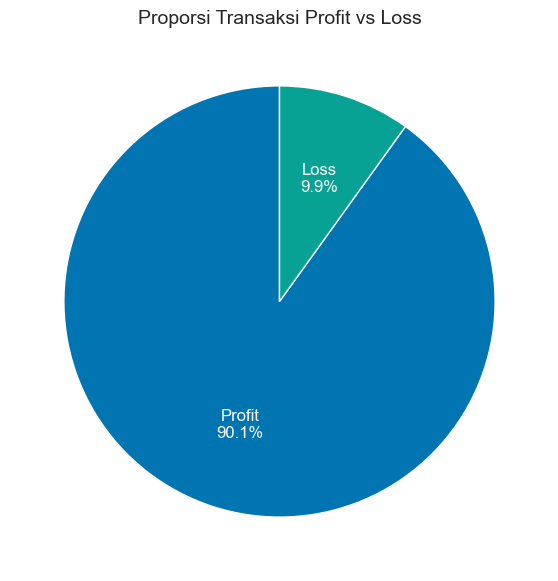

In [71]:
# EDA Univariate 2
# Visualisasi proporsi transaksi profit vs loss untuk melihat
# seberapa besar kontribusi transaksi merugi terhadap keseluruhan transaksi.

profit_counts = pd.Series({"Profit": Total_transaksi - Jumlah_penjualan_minus, "Loss": Jumlah_penjualan_minus})

plt.figure(figsize=(7, 7))
plt.pie(profit_counts,labels=None,autopct=lambda p: f'{"Profit" if p > 50 else "Loss"}\n{p:.1f}%',colors=["#0075b2", "#08a294"],startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1},textprops={"fontsize": 12, "color": "white"})

plt.title("Proporsi Transaksi Profit vs Loss", fontsize=14)
plt.show()

**Interpretasi:**

Sebagian besar transaksi (90,1%) menghasilkan profit positif, sedangkan 9,9% transaksi mengalami kerugian. Meskipun proporsi transaksi rugi relatif kecil, transaksi tersebut tetap perlu dianalisis karena berpotensi memengaruhi profitabilitas secara keseluruhan.

### BIVARIATE ANALYSIS

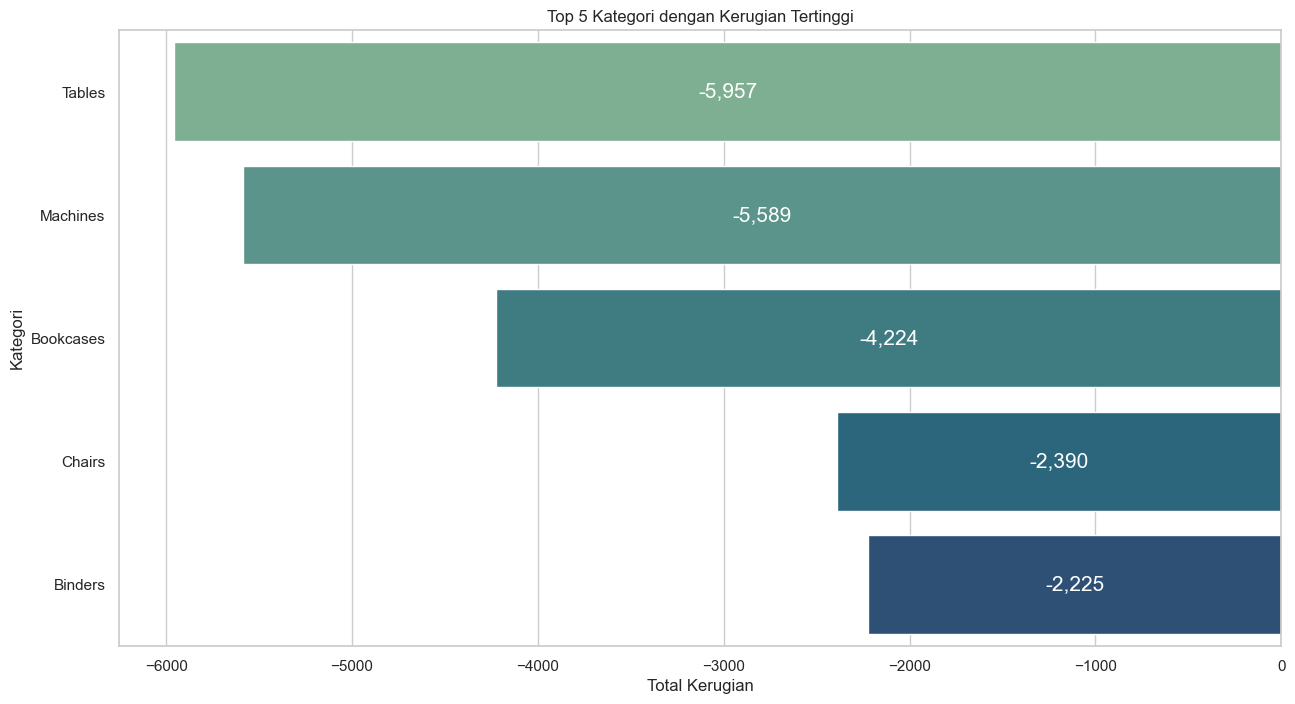

In [72]:
# EDA Bivariate 1
# Mengidentifikasi top 5 kategori dengan total kerugian tertinggi.

loss_cat = (df_loss.groupby("Category")["Profit"].sum().sort_values().head(5).reset_index())

plt.figure(figsize=(15,8))

# Membuat bar chart kategori dengan kerugian tertinggi
ax = sns.barplot(data=loss_cat,x="Profit",y="Category",hue="Category",palette="crest",legend=False)

# Menambahkan label angka di dalam bar
for container in ax.containers:
    
    labels = [f'{(v.get_width()):,.0f}' for v in container]

    ax.bar_label(container,labels=labels,label_type="center",fontsize=15,color="white")

plt.title("Top 5 Kategori dengan Kerugian Tertinggi")
plt.xlabel("Total Kerugian")
plt.ylabel("Kategori")

plt.show()

**Interpretasi:**

Kategori Tables menjadi penyumbang kerugian terbesar dengan total kerugian sekitar -5.957, diikuti oleh Machines dan Bookcases. Sementara itu, Chairs dan Binders juga mengalami kerugian, namun dengan nilai yang relatif lebih rendah dibanding kategori lainnya. Hal ini menunjukkan bahwa kerugian perusahaan lebih banyak terkonsentrasi pada beberapa kategori tertentu.

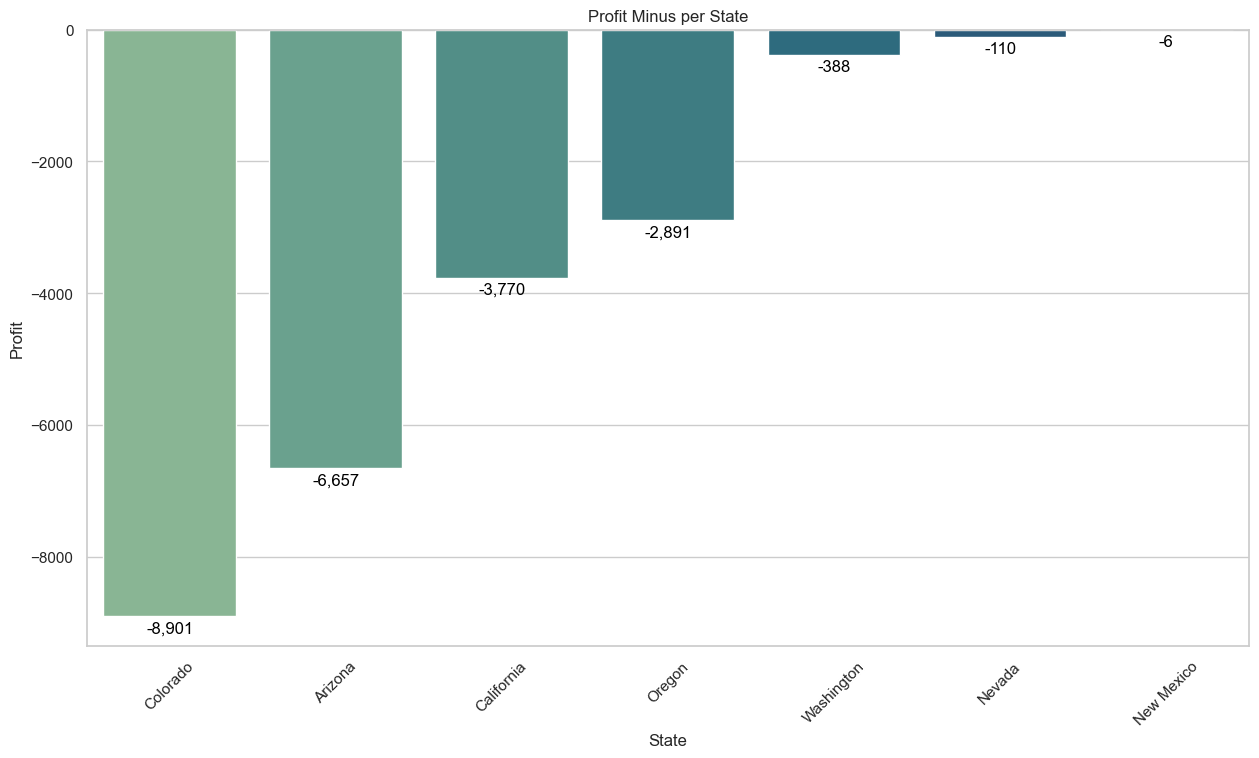

In [73]:
# EDA Bivariate 2
# Mengidentifikasi state dengan total profit minus terbesar.

loss_state = (df_loss.groupby("State")["Profit"].sum().sort_values().reset_index())

plt.figure(figsize=(15,8))

ax = sns.barplot(data=loss_state,x="State",y="Profit",hue="State",palette="crest",legend=False)

# Menambahkan label angka pada bar
for container in ax.containers:
    
    labels = [f'{(v.get_height()):,.0f}'for v in container]

    ax.bar_label(container,labels=labels,fontsize=12,color="black",padding=3)

plt.title("Profit Minus per State")
plt.xlabel("State")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

**Interpretasi:**

Kerugian terbesar paling banyak terjadi di Colorado, dengan nilai yang jauh lebih tinggi dibanding state lain. Setelah itu disusul oleh Arizona dan California. Sementara beberapa state seperti Washington, Nevada, dan New Mexico hanya mengalami kerugian kecil. Hal ini menunjukkan bahwa profit minus lebih terkonsentrasi pada wilayah tertentu dibanding tersebar merata di seluruh state.

### MULTIVARIATE ANALYSIS
#### Korelasi Variabel Numerik Pada Transaksi Profit Minus

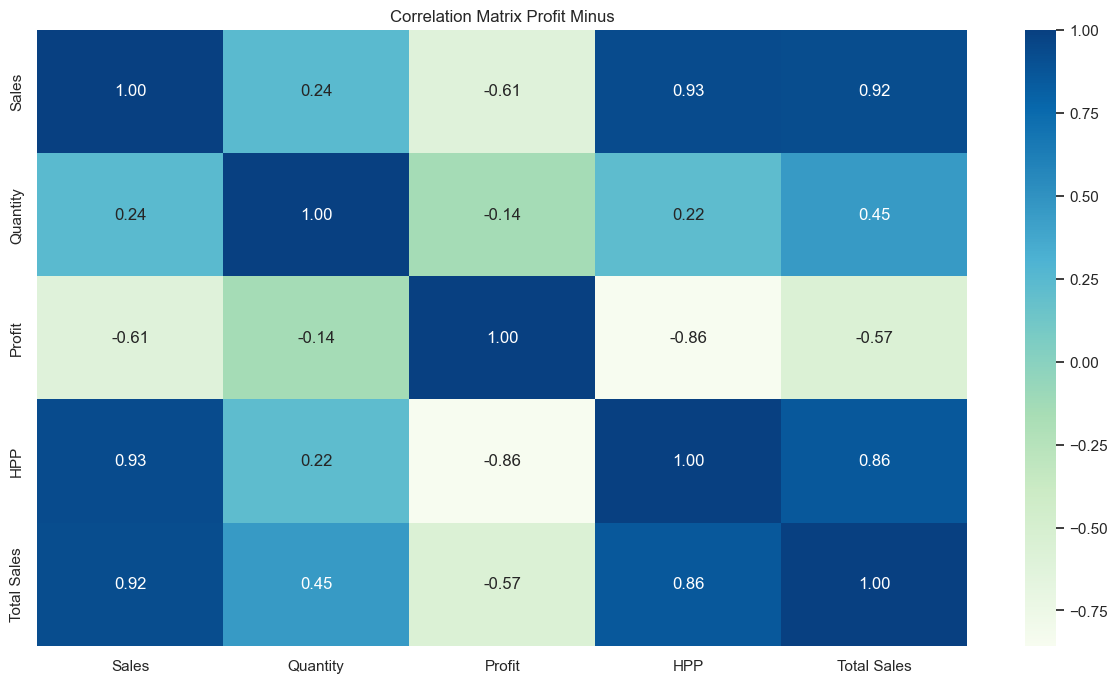

In [74]:
# Melihat korelasi antar variabel numerik pada transaksi profit minus.

plt.figure(figsize=(15,8))

sns.heatmap(df_loss[["Sales","Quantity","Profit","HPP","Total Sales"]].corr(),annot=True,cmap="GnBu",fmt=".2f")

plt.title("Correlation Matrix Profit Minus")

plt.show()

**Interpretasi:**

Pada transaksi yang rugi, biaya produksi terlihat memiliki hubungan paling kuat terhadap profit minus. Artinya, semakin tinggi biaya produksi, kerugian cenderung semakin besar. Harga jual dan total penjualan yang tinggi juga belum tentu membuat transaksi menjadi untung, karena masih ada kemungkinan biaya yang terlalu besar atau margin keuntungan yang kecil. Sementara itu, jumlah barang terjual terlihat tidak terlalu berpengaruh terhadap kerugian.

In [75]:
# Uji Hipotesis
# Mann-Whitney U Test digunakan untuk mengetahui
# apakah terdapat perbedaan HPP antara transaksi
# profit dan profit minus.

from scipy.stats import mannwhitneyu

# Membagi data menjadi dua kelompok
profit = (df_eda[df_eda["Profit"] >= 0]["HPP"])

loss = (df_eda[df_eda["Profit"] < 0]["HPP"])

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(profit,loss,alternative="two-sided")

alpha = 0.05

# Menampilkan hasil
print("=== Uji Hipotesis Mann-Whitney U Test ===")
print(f"Statistik Uji : {stat:.4f}")
print(f"P-Value       : {p_value:.10f}")

if p_value < alpha:
    print("Keputusan     : Tolak H₀")
    print("Interpretasi  : Terdapat perbedaan HPP yang signifikan antara transaksi profit dan loss")
else:
    print("Keputusan     : Gagal Menolak H₀")
    print("Interpretasi  : Tidak terdapat perbedaan HPP yang signifikan antara transaksi profit dan loss")

=== Uji Hipotesis Mann-Whitney U Test ===
Statistik Uji : 295883.5000
P-Value       : 0.0000000000
Keputusan     : Tolak H₀
Interpretasi  : Terdapat perbedaan HPP yang signifikan antara transaksi profit dan loss


## Advanced EDA Techniques

### FILTERING DATA

In [76]:
# Advanced EDA 1
# Melakukan filtering untuk mengambil transaksi dengan profit minus.
df_loss = df_eda[df_eda["Profit"] < 0].copy()

Total_transaksi = df_eda.shape[0]
Jumlah_penjualan_minus = len(df_loss)  # ambil jumlah baris dari df_loss
Persentase_minus = (Jumlah_penjualan_minus / Total_transaksi) * 100

print(f"Jumlah penjualan minus: {Jumlah_penjualan_minus} / {Total_transaksi}")
print(f"Persentase minus: {Persentase_minus:.2f}%")

df_loss.head(1)

Jumlah penjualan minus: 318 / 3203
Persentase minus: 9.93%


,Order ID,Order Date,Ship Date,EmailID,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
28,US-2014-109484,2014-11-07,2014-11-13,RogerBarcio@gmail.com,United States,Portland,Oregon,Binders,flexible leather- look classic collection ring binder,5.68,1,-3.79,9.47,5.68


### RANDOM SAMPLING

In [77]:
# Advanced EDA 2
# Mengambil sampel acak transaksi profit minus.

sample_loss = (df_loss.sample(n=10,random_state=42))
sample_loss.head(5)

,Order ID,Order Date,Ship Date,EmailID,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
628,CA-2012-122287,2012-06-18,2012-06-23,SkyeNorling@gmail.com,United States,Peoria,Arizona,Binders,aluminum screw posts,9.16,2,-6.10,15.26,18.32
2669,CA-2013-144148,2013-08-01,2013-08-06,AnnaHÃ¤berlin@gmail.com,United States,San Francisco,California,Tables,laminate occasional tables,863.13,7,-32.37,895.50,6041.91
195,US-2013-156986,2013-03-21,2013-03-25,ZuschussCarroll@gmail.com,United States,Salem,Oregon,Phones,i.sound portable power - 8000 mah,84.78,2,-20.14,104.92,169.56
2489,US-2013-157490,2013-10-07,2013-10-08,LaurelBeltran@gmail.com,United States,Pueblo,Colorado,Binders,"avery framed view binder, ezd ring (locking), navy, 1 1/2""",11.98,4,-9.18,21.16,47.92
100,CA-2011-129924,2011-07-12,2011-07-17,AlyssaCrouse@gmail.com,United States,San Francisco,California,Tables,hon 5100 series wood tables,698.35,3,-17.46,715.81,2095.05


In [78]:
# Mengambil 30% sampel acak transaksi profit minus.
Persen_loss_sample = df_loss.sample(frac=0.3)
Persen_loss_sample.head(5)

,Order ID,Order Date,Ship Date,EmailID,Country,City,State,Category,Product Name,Sales,Quantity,Profit,HPP,Total Sales
1830,CA-2013-145261,2013-12-19,2013-12-22,AdrianHane@gmail.com,United States,Salem,Oregon,Tables,"iceberg officeworks 42"" round tables",377.45,5,-264.22,641.67,1887.25
627,CA-2012-122287,2012-06-18,2012-06-23,SkyeNorling@gmail.com,United States,Peoria,Arizona,Binders,peel & stick add-on corner pockets,4.54,7,-3.33,7.87,31.78
2540,CA-2012-106257,2012-04-13,2012-04-17,EugeneBarchas@gmail.com,United States,Los Angeles,California,Tables,"iceberg officeworks 42"" round tables",241.57,2,-15.10,256.67,483.14
1214,CA-2011-101931,2011-10-28,2011-10-31,ToddSumrall@gmail.com,United States,Los Angeles,California,Bookcases,o'sullivan living dimensions 2-shelf bookcases,617.00,6,-36.29,653.29,3702.00
1255,CA-2014-101308,2014-10-03,2014-10-08,FrankGastineau@gmail.com,United States,Seattle,Washington,Phones,i.sound portable power - 8000 mah,84.78,2,-20.14,104.92,169.56


### GROUPING DATA

#### Statistik Agregat per Kategory

In [79]:
# Advanced EDA 3
# Menerapkan teknik grouping untuk menghitung statistik agregat
# berdasarkan kategori produk.

# Grouping berdasarkan Category
group_category = (df_eda.groupby("Category")
                  .agg(Jumlah_Transaksi=("Profit","count"),
                       Total_Sales=("Total Sales","sum"),
                       Avg_Sales=("Sales","mean"),
                       Total_Profit=("Profit","sum"),
                       Avg_Profit=("Profit","mean"),
                       Transaksi_Minus=("Profit",lambda x: (x < 0).sum())).round(2).reset_index())

# Menambahkan persentase transaksi profit minus per kategori
group_category["Pct_Minus (%)"] = ((group_category["Transaksi_Minus"] /group_category["Jumlah_Transaksi"]) * 100).round(2)

group_category

,Category,Jumlah_Transaksi,Total_Sales,Avg_Sales,Total_Profit,Avg_Profit,Transaksi_Minus,Pct_Minus (%)
0,Accessories,258,333767.41,236.88,16484.62,63.89,19,7.36
1,Appliances,136,161638.88,222.33,8261.29,60.74,0,0.00
2,Art,250,49323.30,36.85,2374.15,9.50,0,0.00
3,Binders,471,272316.66,118.81,16096.78,34.18,77,16.35
4,Bookcases,80,190863.74,450.05,-1646.50,-20.58,32,40.00
5,Chairs,207,445983.13,491.70,4027.62,19.46,67,32.37
6,Copiers,25,215726.70,1989.97,19327.25,773.09,0,0.00
7,Envelopes,67,15449.32,61.46,1908.71,28.49,0,0.00
8,Fasteners,72,4726.97,12.82,275.19,3.82,4,5.56
9,Furnishings,304,154817.88,98.92,7641.26,25.14,7,2.30


#### Visualisasi Statistik Agregat per Kategori

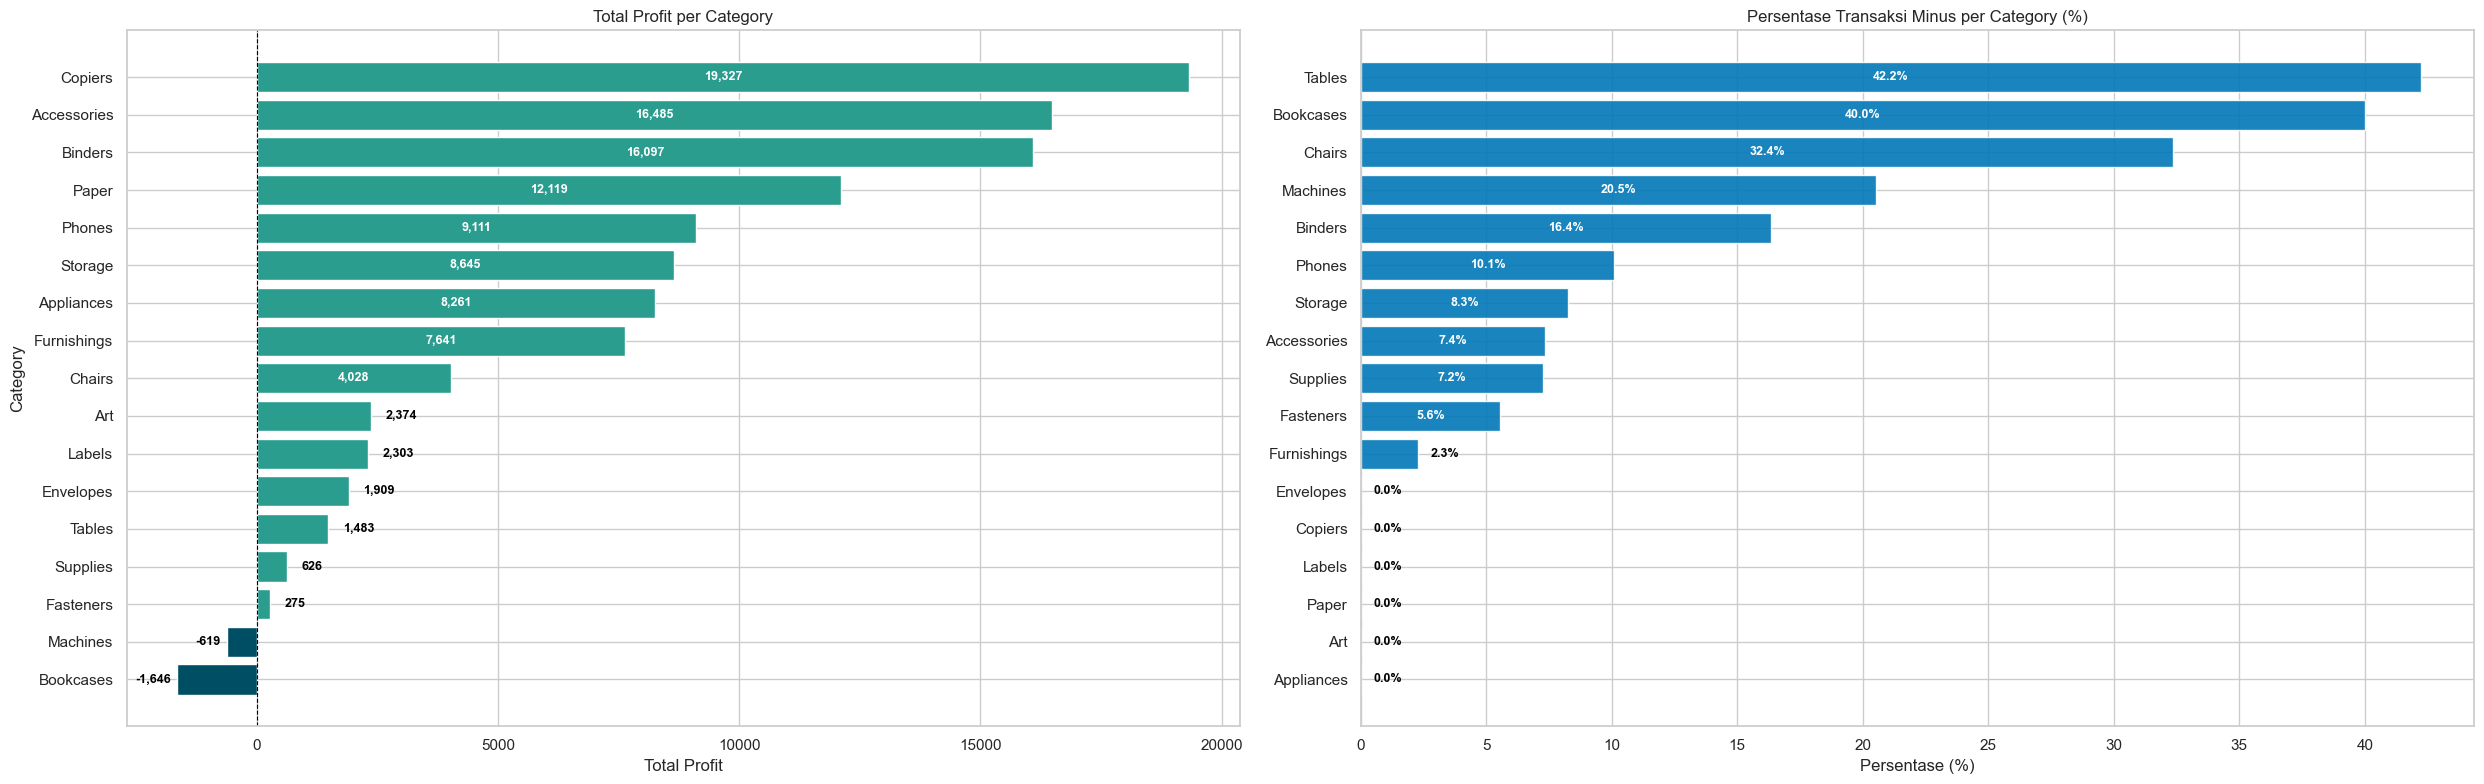

In [80]:
# Membuat visualisasi hasil grouping per category.

# Mengurutkan category berdasarkan total profit
group_category_profit = (group_category.sort_values("Total_Profit"))

fig, axes = plt.subplots(1,2,figsize=(25,8))

# Panel kiri: Total Profit per Category
# Memberikan warna hijau untuk profit positif dan biru untuk profit negatif
bar_colors = [colors[2] if v >= 0 else colors[0]
              for v in group_category_profit["Total_Profit"]]

bars1 = axes[0].barh(group_category_profit["Category"],
                     group_category_profit["Total_Profit"],
                     color=bar_colors)

axes[0].axvline(x=0,color="black",linewidth=0.8,linestyle="--")

axes[0].set_title("Total Profit per Category")
axes[0].set_xlabel("Total Profit")
axes[0].set_ylabel("Category")

# Menambahkan label nilai pada setiap bar
for bar in bars1:
    
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height()/2

    # Jika bar kecil, label di luar
    if abs(width) < 2500:
        posisi = width + 300 if width >= 0 else width - 120
        warna = "black"
        ha = "left" if width >= 0 else "right"
    
    # Jika bar besar, label di dalam
    else:
        posisi = width/2
        warna = "white"
        ha = "center"

    axes[0].text(posisi,y_pos,f"{width:,.0f}",
                 ha=ha,
                 va="center",
                 fontsize=9,
                 color=warna,
                 fontweight="bold")

# Panel kanan: Persentase transaksi minus per Category
group_category_pct = (group_category.sort_values("Pct_Minus (%)")
                      .reset_index(drop=True))

bars2 = axes[1].barh(group_category_pct["Category"],
                     group_category_pct["Pct_Minus (%)"],
                     color=colors[1],
                     alpha=0.9)

axes[1].set_title("Persentase Transaksi Minus per Category (%)")
axes[1].set_xlabel("Persentase (%)")
axes[1].set_ylabel("")

# Menambahkan label persentase pada setiap bar
for bar in bars2:
    
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height()/2

    # Jika bar kecil, label di luar
    if width < 5:
        posisi = width + 0.5
        warna = "black"
        ha = "left"
    
    # Jika bar besar, label di dalam
    else:
        posisi = width/2
        warna = "white"
        ha = "center"

    axes[1].text(posisi,y_pos,f"{width:.1f}%",
                 ha=ha,
                 va="center",
                 fontsize=9,
                 color=warna,
                 fontweight="bold")

plt.tight_layout()
plt.show()

#### Top 5 Produk Paling Rugi

In [81]:
# Advanced EDA 4
# Menerapkan teknik grouping untuk mengidentifikasi
# produk dengan total profit minus terbesar.

loss_product = (df_loss.groupby("Product Name")
                .agg({"Profit":"sum",
                      "Sales":"mean",
                      "HPP":"mean",
                      "Quantity":"sum"}).sort_values(by="Profit").head(5).round(2).reset_index())

loss_product

,Product Name,Profit,Sales,HPP,Quantity
0,lexmark mx611dhe monochrome laser printer,-3399.98,2549.99,5949.97,5
1,zebra gk420t direct thermal/thermal transfer printer,-938.28,703.71,1641.99,6
2,o'sullivan 4-shelf bookcase in odessa pine,-833.56,157.27,435.13,13
3,bush advantage collection racetrack conference table,-814.48,1272.63,2087.11,6
4,"atlantic metals mobile 4-shelf bookcases, custom colors",-786.74,590.06,1376.80,7


#### Visualisasi Top 5 Produk paling rugi

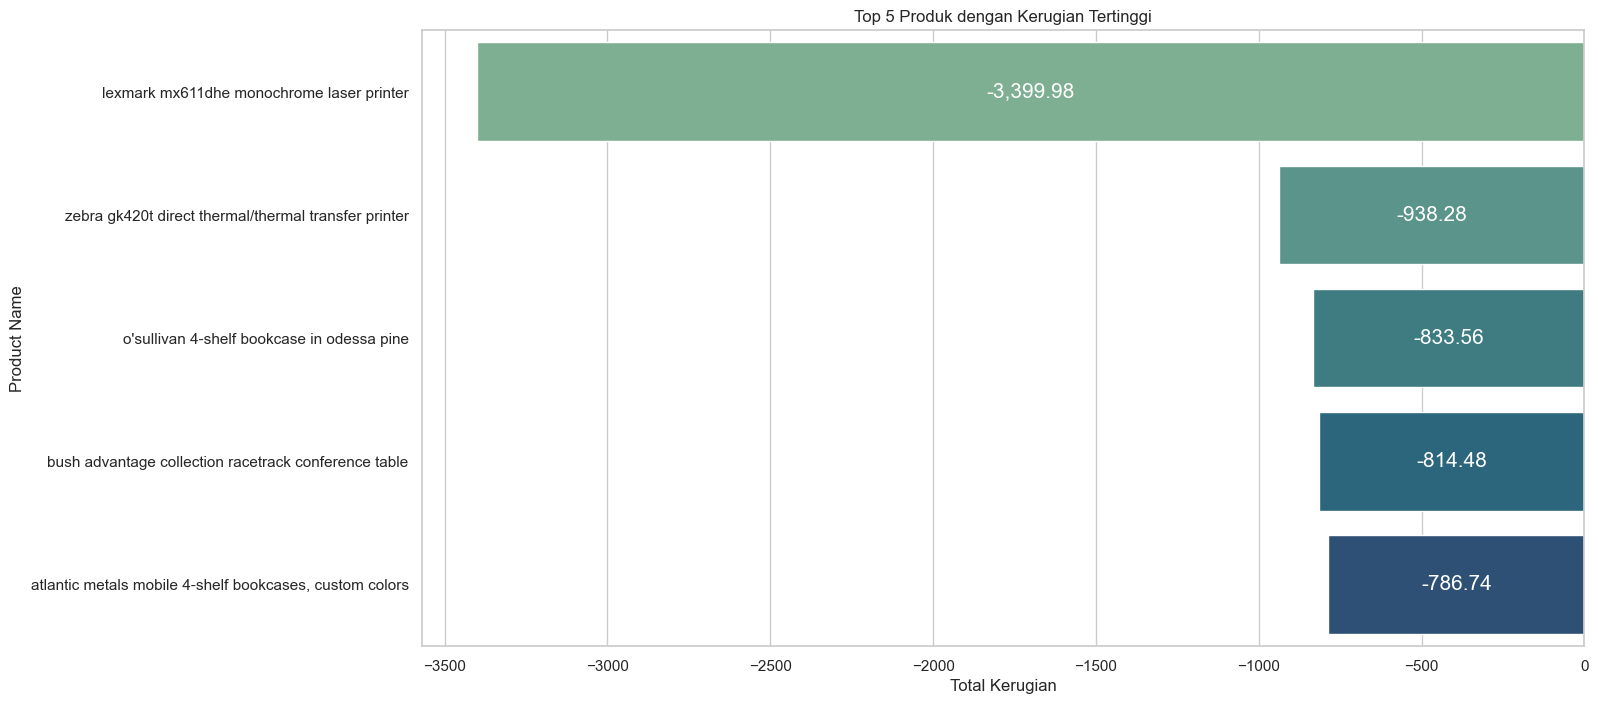

In [82]:
# Visualisasi produk dengan kerugian terbesar

loss_product_plot = (df_loss.groupby("Product Name")["Profit"].sum().sort_values().head(5).reset_index())

plt.figure(figsize=(15,8))

ax = sns.barplot(data=loss_product_plot,x="Profit",y="Product Name",hue="Product Name",palette="crest",legend=False)

for container in ax.containers:
    
    labels = [f'{(v.get_width()):,.2f}'
              for v in container]

    ax.bar_label(container,labels=labels,label_type="center",fontsize=15,color="white")

plt.title("Top 5 Produk dengan Kerugian Tertinggi")
plt.xlabel("Total Kerugian")
plt.ylabel("Product Name")

plt.show()

**Interpretasi:**

Kerugian terbesar paling banyak berasal dari Lexmark MX611dhe Monochrome Laser Printer, dengan total kerugian mencapai -3.400. Selain itu, beberapa produk lainnya seperti thermal transfer printer, bookscases, dan conference table juga termasuk penyumbang kerugian terbesar. Ini menunjukkan bahwa profit minus kemungkinan tidak terjadi secara merata, tetapi lebih terkonsentrasi pada produk tertentu.

### CROSS TABULATION

In [83]:
# Advanced EDA 5
# Melakukan cross tabulation antara category dan state pada transaksi minus.

cross_tab = pd.crosstab(df_loss["Category"],df_loss["State"],margins=True,margins_name="Total")

cross_tab

State,Arizona,California,Colorado,Nevada,New Mexico,Oregon,Washington,Total
Category,,,,,,,,
Accessories,10,0,5,0,0,4,0,19
Binders,35,0,28,0,0,14,0,77
Bookcases,3,17,9,0,0,3,0,32
Chairs,6,42,2,1,0,4,12,67
Fasteners,2,0,1,0,0,1,0,4
Furnishings,3,0,3,0,0,1,0,7
Machines,3,0,3,0,0,2,0,8
Phones,1,15,2,0,1,4,5,28
Storage,11,0,8,0,0,3,0,22


**Interpretasi:**

Berdasarkan cross tabulation transaksi minus, California memiliki jumlah transaksi kerugian tertinggi, diikuti oleh Arizona dan Colorado. Dari sisi kategori, kerugian paling banyak terjadi pada Binders, Chairs, dan Tables, yang menunjukkan bahwa kategori tersebut lebih sering terlibat dalam transaksi dengan profit negatif dibanding kategori lainnya.

## Insight & Kesimpulan
### Insight Utama

Berdasarkan hasil Exploratory Data Analysis (EDA) terhadap dataset Amazon Sales, diperoleh beberapa insight utama sebagai berikut:

1. Masih terdapat transaksi profit minus meskipun mayoritas transaksi menghasilkan keuntungan

Distribusi profit menunjukkan pola right-skewed, di mana sebagian besar transaksi menghasilkan profit dalam jumlah kecil hingga menengah. Sebanyak 9,93% transaksi (318 dari 3.203 transaksi) mengalami profit minus. Mayoritas kerugian tergolong kecil, namun terdapat beberapa transaksi dengan nilai kerugian yang cukup besar (outlier) yang berpotensi memengaruhi profitabilitas secara keseluruhan.

2. Kerugian tidak terjadi secara merata, tetapi terkonsentrasi pada kategori, produk dan wilayah tertentu

Kategori Tables, Machines, dan Bookcases dan Produk Lexmark MX611dhe Monochrome Laser Printer menjadi penyumbang profit minus terbesar. Dari sisi wilayah, Colorado, Arizona, dan California merupakan state dengan total profit minus tertinggi. Hal ini menunjukkan bahwa transaksi rugi lebih banyak terkonsentrasi pada kelompok tertentu dibanding tersebar merata pada seluruh kategori dan wilayah.

3. Sales tinggi tidak selalu menghasilkan profit yang tinggi

Meskipun terdapat hubungan yang cukup kuat antara Sales dan Profit (0,65), peningkatan nilai sales tidak selalu diikuti oleh profit yang lebih besar. Beberapa transaksi dengan sales tinggi tetap menghasilkan profit rendah bahkan negatif, menunjukkan bahwa tingginya penjualan belum tentu mencerminkan profitabilitas yang baik.

4. HPP menjadi faktor yang paling berkaitan dengan profit minus

Pada transaksi yang mengalami kerugian, HPP menunjukkan hubungan negatif paling kuat terhadap Profit (-0,86) dibanding variabel lainnya, sedangkan Quantity memiliki hubungan yang relatif lemah. Temuan ini menunjukkan bahwa kerugian lebih berkaitan dengan tingginya biaya produksi (HPP) dibanding jumlah barang yang terjual.

## Kesimpulan
### Perspektif Analitik

Sebagian besar variabel numerik menunjukkan distribusi yang tidak normal dan mengandung outlier, sehingga pendekatan analisis non-parametrik lebih sesuai digunakan. Selain itu, pada transaksi profit minus ditemukan bahwa HPP memiliki hubungan paling kuat terhadap profit, dibandingkan variabel numerik lainnya.

### Perspektif Bisnis

Profit minus pada dataset Amazon Sales tidak terjadi secara acak, melainkan menunjukkan pola tertentu berdasarkan kategori produk, produk, dan  wilayah, dan biaya produksi. Kategori seperti Tables, Machines, dan Bookcases, serta state seperti Colorado dan Arizona, menunjukkan performa profit yang relatif lebih rendah. Oleh karena itu, evaluasi terhadap strategi harga, efisiensi biaya produksi, serta performa produk dan wilayah tertentu dapat menjadi langkah untuk mengurangi potensi transaksi rugi di masa mendatang.

In [84]:
# Simulasi profit tahunan berdasarkan skenario profit minus

# Menyalin data agar data asli tidak berubah
df_simulasi = df_eda.copy()

# Mengambil tahun transaksi
df_simulasi["Year"] = df_simulasi["Order Date"].dt.year

# Profit aktual pertahun
profit_actual = (df_simulasi.groupby("Year")["Profit"].sum().reset_index())

# ==========================
# Skenario 1: Tidak ada minus
# ==========================

# Mengubah seluruh profit negatif menjadi 0
df_simulasi["Profit_NoMinus"] = (df_simulasi["Profit"].apply(lambda x: 0 if x < 0 else x))

profit_no_minus = (df_simulasi.groupby("Year")["Profit_NoMinus"].sum().reset_index())

# ==========================
# Skenario 2: Minus hanya 1%
# ==========================

# Menyalin data profit
df_simulasi["Profit_1Pct"] = df_simulasi["Profit"]

# Mengambil transaksi rugi
minus_idx = (df_simulasi[df_simulasi["Profit"] < 0].index)

# Menentukan jumlah transaksi minus 1%
jumlah_minus_1pct = int(len(df_simulasi) * 0.01)

# Memilih transaksi rugi terbesar yang tetap dipertahankan
minus_keep = (df_simulasi.loc[minus_idx].sort_values("Profit").head(jumlah_minus_1pct).index)

# Mengubah transaksi minus selain 1% menjadi 0
df_simulasi.loc[ (~df_simulasi.index.isin(minus_keep)) &(df_simulasi["Profit"] < 0),"Profit_1Pct"] = 0

profit_1pct = (df_simulasi.groupby("Year")["Profit_1Pct"].sum().reset_index())

# Menggabungkan hasil simulasi profit tahunan
profit_compare = (profit_actual.merge(profit_no_minus,on="Year").merge(profit_1pct,on="Year"))

profit_compare

,Year,Profit,Profit_NoMinus,Profit_1Pct
0,2011,20065.74,23457.45,21982.57
1,2012,20492.17,24377.46,22290.79
2,2013,23959.90,30338.43,25559.99
3,2014,43900.98,52966.58,46806.19


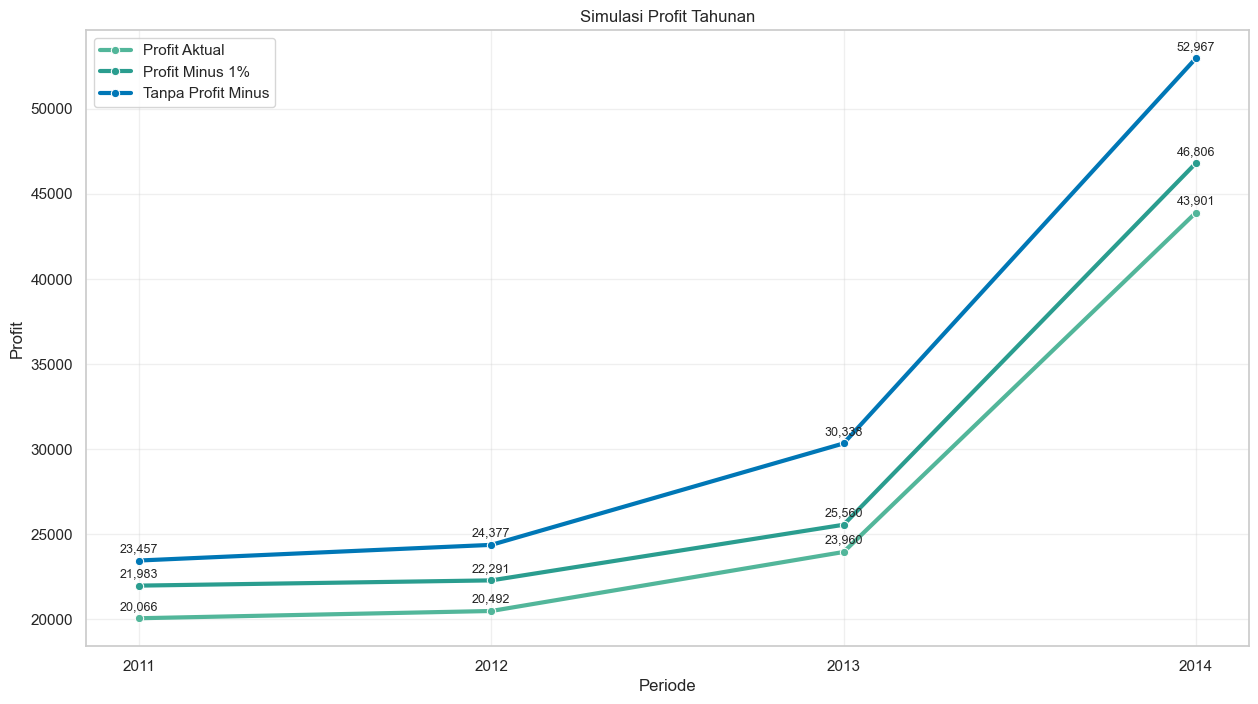

In [85]:
# Visualisasi simulasi profit tahunan

plt.figure(figsize=(15,8))

# Menghitung total profit pertahun
yearly_profit = (df_eda.groupby(df_eda["Order Date"].dt.to_period("Y"))["Profit"].sum().reset_index())

# Mengubah format periode menjadi string
yearly_profit["Order Date"] = yearly_profit["Order Date"].astype(str)

# Mengubah format periode untuk simulasi
profit_no_minus["Year"] = profit_no_minus["Year"].astype(str)
profit_1pct["Year"] = profit_1pct["Year"].astype(str)

sns.lineplot(data=yearly_profit,x="Order Date",y="Profit",marker="o",linewidth=3,color=colors[3],label="Profit Aktual")

sns.lineplot(data=profit_1pct,x="Year",y="Profit_1Pct",marker="o",linewidth=3,color=colors[2],label="Profit Minus 1%")

sns.lineplot(data=profit_no_minus,x="Year",y="Profit_NoMinus",marker="o",linewidth=3,color=colors[1],label="Tanpa Profit Minus")

# Menambahkan label profit aktual
for x, y in zip(yearly_profit["Order Date"],yearly_profit["Profit"]):
    plt.text(x,y+500,f"{y:,.0f}",ha="center",fontsize=9)

# Menambahkan label profit tanpa minus
for x, y in zip(profit_no_minus["Year"],profit_no_minus["Profit_NoMinus"]):
    plt.text(x,y+500,f"{y:,.0f}",ha="center",fontsize=9)

# Menambahkan label profit minus 1%
for x, y in zip(profit_1pct["Year"],profit_1pct["Profit_1Pct"]):
    plt.text(x,y+500,f"{y:,.0f}",ha="center",fontsize=9)

plt.title("Simulasi Profit Tahunan")
plt.xlabel("Periode")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## Interpretasi:

Simulasi menunjukkan bahwa profit tahunan berpotensi meningkat apabila transaksi profit minus dapat ditekan. Pada skenario tanpa profit minus, profit meningkat paling tinggi di seluruh tahun pengamatan. Sementara pada skenario profit minus hanya 1%, profit tetap meningkat dibanding kondisi aktual, meskipun belum sebesar skenario tanpa kerugian. Hal ini menunjukkan bahwa pengurangan transaksi rugi berpotensi memberikan dampak signifikan terhadap profitabilitas perusahaan.